<a href="https://colab.research.google.com/github/Oumayyyyma/SLF-DF/blob/main/Sybil_wallet_work_official_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librairies utiles pour notre travail
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from collections import Counter

# Chemin des fichiers CSV
path = '/Users/dylan/10000h/DATA/Python/JDD/'

# Importer les fichiers CSV dans des DataFrames
df1 = pd.read_csv(f'{path}all_wallets.csv')
df3 = pd.read_csv(f'{path}potencial_sybil_wallets.csv')

# D'ou proviennent les données ?

Les 9 variables communes présentes dans les fichiers **all_wallets.csv** et **potential_sybil_wallets.csv** ont été obtenues grâce à différentes requêtes, précisément trois, dont nous allons expliquer le contenu :

- **La première requête** disponible à l'adresse [https://dune.com/queries/3711850](https://dune.com/queries/3711850) qui permet de tracker les portefeuilles sybils, fournit un aperçu complet de l'activité des portefeuilles sur Arbitrum, incluant les transactions, le gaz dépensé, les interactions avec des contrats uniques, ainsi que les NFT transférés et mintés.
  
- **La seconde requête** ( [https://dune.com/queries/3711970](https://dune.com/queries/3711970) ),permettant de déterminer le nombre de chaînes de blocs distinctes avec lesquelles chaque portefeuille a interagi, qui n'est plus accessible aujourd'hui ou est devenue privée, fournit les mêmes informations que la requête précédente avec une variable supplémentaire indiquant le nombre de réseaux blockchain uniques avec lesquels le portefeuille a interagi tout au long de son existence.

- **La troisième requête** ( [https://dune.com/queries/3715970](https://dune.com/queries/3715970) ) donne l'adresse du portefeuille et le nombre de contrats uniques avec lesquels le portefeuille a interagi. Elle a été utilisée pour rassembler toutes les métriques, en raison des restrictions de Dune concernant l'utilisation de plusieurs vues de requêtes. La seule information supplémentaire fournie par cette requête est la liste des chaînes (`chains_list`) avec lesquelles les adresses ont interagi.


# Que décrivent les jeux de données que nous allons exploiter ?

Notre priorité sera d'étudier ce fichier. Voici une description succinte des variables :

- **address** : Adresse du portefeuille. *(champ `address`)*
- **first_interact** : Date de la première transaction exécutée par le portefeuille sur Arbitrum. *(champ `first_interaction`)*
- **last_interact** : Date de la dernière transaction exécutée par le portefeuille sur Arbitrum. *(champ `last_interaction`)*
- **distinct_chains** : Nombre de réseaux de chaînes de blocs uniques avec lesquels le portefeuille a interagi tout au long de sa vie. *(champ `distinct_chains`)*
- **chains_list** : Liste des réseaux de chaînes de blocs avec lesquels le portefeuille a interagi. *(champ `chains_list`)*
- **gas_spent_eth** : Quantité totale de gaz dépensée par le portefeuille en ETH sur Arbitrum. *(champ `gas_spent`)*
- **tx_count** : Nombre total de transactions exécutées sur Arbitrum par l'adresse tout au long de sa vie. *(champ `tx_count`)*
- **unique_contracts** : Nombre de contrats uniques avec lesquels le portefeuille a interagi sur Arbitrum. *(champ `unique_contracts`)*
- **unique_nft_addresses** : Liste des adresses NFT uniques transférées depuis le portefeuille sur Arbitrum. *(champ `unique_nft_addresses`)*


# Sommaire
Première partie : classification binaires des adresses sybils
### [Étape 1 : Comprendre le contexte](#étape-1--comprendre-le-contexte)
### [Étape 2 : Exploration des données](#étape-2--exploration-des-données)
### [Étape 3 : Description univariée des données](#étape-3--description-univariée-des-données)
### [Étape 4 : Analyse bivariée](#étape-4--analyse-bivariée)
### [Étape 5 : Feature Engineering pour les futurs modèles](#étape-5--feature-engineering-pour-les-futurs-modèles)
### [Étape 6 : Construction de modèle](#étape-6--construction-de-modèle)

## Étape 1 : Comprendre le contexte
<a id="étape-1--comprendre-le-contexte"></a>
**Quelle est la problématique métier ?**
- L'objectif de notre démarche est de développer un modèle de machine learning capable de distinguer les adresses Sybil des adresses non-Sybil. Comme le souligne un article de Nasdaq ([lien](https://www.nasdaq.com/articles/sybil-accounts-the-big-risk-new-airdrop-farmers-are-overlooking)), être identifié comme un compte Sybil signifie qu'un algorithme a détecté l'utilisation de plusieurs adresses de portefeuille dans le seul but de collecter des airdrops. Dans le cadre de notre étude, bien que les fichiers *all_wallets* et *potential_sybil_wallets* ne soient pas étiquetés, nous ajouterons une étiquette Sybil au premier fichier. Cela nous permettra d'analyser en profondeur les différents motifs de comportement entre les adresses Sybil et celles qui ne le sont pas.

**Sommaire des visualisation**

- **Visualisation 1** : densité et boxplot des variables quantitatives pour les adresses sybils
- **Visualisation 2** : countplot des variables qualitatives pour les adresses sybils
- **Visualisation 3** : densité et boxplot des variables quantitatives pour les adresses non-sybils
- **Visualisation 4** : countplot des variables qualitatives pour les adresses non-sybils
- **Visualisation 5** : barplot des fréquences d'interaction avec les différentes chaînes pour les adresses sybils et non-sybils sans condition de sélection
- **Visualisation 6** : barplot des fréquences d'interaction avec les différentes chaînes pour les adresses sybils et non-sybils avec sélection d'observation n°1
- **Visualisation 7** : barplot des fréquences d'interaction avec les différentes chaînes pour les adresses sybils et non-sybils avec sélection d'observation n°2
- **Visualisation 8** : barplot des fréquences d'interaction avec les différentes chaînes pour les adresses sybils et non-sybils avec sélection d'observation n°3
- **Visualisation 9** : barplot des fréquences d'interaction avec les différentes chaînes pour les adresses sybils et non-sybils avec sélection d'observation n°4
- **Visualisation 10** : analyse de densité superposée des adresses sybils et non-sybils
- **Visualisation 11** : ré-étude de la densité superposée pour la variable `gas_spent_eth`
- **Visualisation 12** : ré-étude de la densité superposée pour la variable `gas_spent_eth`
- **Visualisation 13** : boxplot des dépenses de gaz selon le type d’adresses
- **Visualisation 14** : matrice de corrélation appliquée sur toutes les adresses sybils
- **Visualisation 15** : matrice de corrélation appliquée sur les adresses non-sybils
- **Visualisation 16** : heatmap des variables qualitatives pour les adresses sybils
- **Visualisation 17** : heatmap des variables qualitatives pour les adresses non-sybils

## Étape 2 : Exploration des données
<a id="étape-2--exploration-des-données"></a>

**Essentiel du jeu de données**
- Le DataFrame `df1`, initialement composé de 9 variables, a été soumis à plusieurs étapes de nettoyage et de transformation, y compris la suppression de colonnes avec des valeurs manquantes, la gestion des doublons, l'ajout d'une étiquette pour identifier les adresses "Sybil", et la conversion de certaines colonnes en types appropriés, avant de mettre à jour ses informations via `df1.info()` pour refléter la structure finale des données, qui inclut le nombre de variables, le nombre de lignes, et la présence ou l'absence de valeurs manquantes.

In [ ]:
# Description succincte de l'essentiel du jeu de données (nombre de lignes, nombre de variables, comptage des valeurs non nulles, types de données...)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370438 entries, 0 to 370437
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   address               370438 non-null  object 
 1   first_interact        370438 non-null  object 
 2   last_interact         370438 non-null  object 
 3   distinct_chains       370438 non-null  int64  
 4   chains_list           370438 non-null  object 
 5   gas_spent_eth         370438 non-null  float64
 6   tx_count              370438 non-null  int64  
 7   unique_contracts      370438 non-null  int64  
 8   unique_nft_addresses  105107 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 25.4+ MB


In [ ]:
# Pour avoir une idée des valeurs prises par les variables
df1.head()

,address,first_interact,last_interact,distinct_chains,chains_list,gas_spent_eth,tx_count,unique_contracts,unique_nft_addresses
0,0x9161d214972a52958f5a38695a524db4ec8b77de,2023-12-01 13:32:39.000 UTC,2024-04-22 10:31:45.000 UTC,1,[arbitrum],0.202633,275,29,NaN
1,0xca01a7d566d244369aa2c68fe9599d1778888888,2023-06-16 07:40:37.000 UTC,2024-04-10 09:30:38.000 UTC,2,[goerli arbitrum],0.198780,275,28,[0xbda90f447476e6ea5b78c28dfb6da6916327483e 0x...
2,0xfcaa07a4a18cc908d34940935d636d7de0763afe,2023-12-02 08:39:11.000 UTC,2024-04-15 04:06:34.000 UTC,3,[bnb ethereum arbitrum],0.053277,275,28,[0x7d5203e74a2afe3f474e21fef3e6ce04757652b9 0x...
3,0xfe2dd9c25c89a57c544ca7f82581ed4403d597fb,2024-02-18 09:00:58.000 UTC,2024-05-11 11:59:24.000 UTC,5,[base optimism arbitrum ethereum bnb],0.016917,275,27,[0x4f205d69834f9b101b9289f7affac9b77b3ff9b7]
4,0xfba0d5a2177b17d72e4f8e6ea35b98db507b510a,2023-06-25 12:09:22.000 UTC,2024-04-20 12:29:55.000 UTC,8,[base bnb arbitrum goerli ethereum zksync poly...,0.033302,275,26,[0x77194621143f0693394430953a3fedda1ec0f5b3 0x...


In [ ]:
# Calculer la part de valeurs manquantes pour chaque colonne
missing_percentage = df1.isnull().mean() * 100

# Afficher les résultats
print("Part de valeurs manquantes pour chaque variable (%):")
print(missing_percentage)

Part de valeurs manquantes pour chaque variable (%):
address                  0.000000
first_interact           0.000000
last_interact            0.000000
distinct_chains          0.000000
chains_list              0.000000
gas_spent_eth            0.000000
tx_count                 0.000000
unique_contracts         0.000000
unique_nft_addresses    71.626291
dtype: float64


Il est préférable de supprimer la variable `unique_nft_addresses` en raison de sa part importante de valeurs manquantes.

In [ ]:
df1 = df1.drop(columns = 'unique_nft_addresses')

In [ ]:
# Trouver les lignes dupliquées
df1.duplicated(keep=False).unique()

array([False])

Il n'y a pas de doublon.

### Ajout de l'étiquette Sybil sur df1

Il suffit d'étiqueter toutes les adresses en utilisant les informations disponibles dans les DataFrames `df1` et `df3`. En effet, `df1` contient toutes les adresses, tandis que `df3` répertorie spécifiquement les adresses Sybil. Par conséquent, l'étiquetage est une opération directe et simple à réaliser.

In [ ]:
# Initialiser la colonne 'sybil' dans df1 avec 0
df1['sybil'] = 0

# Trouver les adresses présentes dans df3
addresses_in_df3 = df3['address']

# Mettre à jour la colonne 'sybil' à 1 pour les adresses présentes dans df3
df1.loc[df1['address'].isin(addresses_in_df3), 'sybil'] = 1

In [ ]:
# Calculer la part de valeurs manquantes pour chaque colonne
missing_data = df1.isnull().mean() * 100

# Afficher les résultats
print("Part de valeurs manquantes pour chaque variable (%):")
print(missing_data)

Part de valeurs manquantes pour chaque variable (%):
address             0.0
first_interact      0.0
last_interact       0.0
distinct_chains     0.0
chains_list         0.0
gas_spent_eth       0.0
tx_count            0.0
unique_contracts    0.0
sybil               0.0
dtype: float64


### Conversion et création de variables

In [ ]:
# Convertir la colonne 'sybil' en type catégoriel
df1['sybil'] = pd.Categorical(df1['sybil'])

In [ ]:
# distinct_chains doit être qualitative au vue des valeurs discrêtes
df1['distinct_chains'] = df1['distinct_chains'].astype('category')
df1['unique_contracts'] = df1['unique_contracts'].astype('category')

In [ ]:
# Convertir les colonnes 'first_interact' et 'last_interact' en format datetime
df1['first_interact'] = pd.to_datetime(df1['first_interact'])
df1['last_interact'] = pd.to_datetime(df1['last_interact'])

# Convertir en timestamp Unix (secondes depuis l'époque Unix)
df1['first_interact_unix'] = df1['first_interact'].astype(int) / 10**9
df1['last_interact_unix'] = df1['last_interact'].astype(int) / 10**9
df1['duration'] = df1['last_interact_unix'] - df1['first_interact_unix']

In [ ]:
# Supprimer les colonnes 'first_interact' et 'last_interact'
df1 = df1.drop(columns=['first_interact', 'last_interact'])

In [ ]:
# Typage à jour de nos données
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370438 entries, 0 to 370437
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   address              370438 non-null  object  
 1   distinct_chains      370438 non-null  category
 2   chains_list          370438 non-null  object  
 3   gas_spent_eth        370438 non-null  float64 
 4   tx_count             370438 non-null  int64   
 5   unique_contracts     370438 non-null  category
 6   sybil                370438 non-null  category
 7   first_interact_unix  370438 non-null  float64 
 8   last_interact_unix   370438 non-null  float64 
 9   duration             370438 non-null  float64 
dtypes: category(3), float64(4), int64(1), object(2)
memory usage: 20.8+ MB


- Le choix de convertir en variables qualitatives les colonnes `distinct_chains` et `unique_contracts` vient du fait que les valeurs qu'elles prennent sont discrètes, non continues, et ont un nombre raisonnable de modalités.
- La conversion en timestamp Unix a été effectuée car elle facilite les calculs de durées, notamment pour la création de la variable `duration`.
- La suppression des premières colonnes temporelles a été réalisée car la manipulation des secondes est plus simple dans notre contexte, où nous ne nous intéressons qu'au début et à la fin de chaque interaction (notamment avec Arbitrum).

## Étape 3 : Description univariée des données
<a id="étape-3--description-univariée-des-données"></a>
Pour explorer les caractéristiques de chaque variable de manière univariée, nous utiliserons des visualisations adaptées :

- **Visualisations :**
  - **Boxplots et courbes de densité** seront employés pour analyser la distribution et la dispersion des variables quantitatives. Ces graphiques permettront de mieux comprendre les variations, les tendances centrales, ainsi que les éventuelles valeurs aberrantes.
  - **Diagrammes en barres** seront utilisés pour illustrer les fréquences et les répartitions des variables qualitatives. Ces visualisations mettront en évidence les catégories dominantes et fourniront un aperçu clair des modalités de chaque variable.

Cette approche nous permettra de saisir les caractéristiques fondamentales des données et d'identifier des patterns clés pour les étapes d'analyse ultérieures.

Lors des prochaines analyses, la variable sybil jouera un rôle central. Il sera essentiel de l'exploiter de manière approfondie pour identifier les motifs caractéristiques des adresses sybils et non-sybils. Les jeux de données df_sybil et df_non_sybil seront donc crées :

In [ ]:
# Création du DataFrame df_sybil avec les adresses sybils
df_sybil = df1[df1['sybil'] == 1].copy()

# Création du DataFrame df_non_sybil avec les adresses non-sybils
df_non_sybil = df1[df1['sybil'] == 0].copy()


### La stratégie d'analyse univariée mise en place

La courbe de densité illustre la forme globale de la distribution des valeurs, tandis que le boxplot fournit un résumé des statistiques descriptives et met en évidence les valeurs aberrantes, offrant ainsi une complémentarité précieuse pour analyser les données.

La médiane, représentée par la ligne à l'intérieur de la boîte du boxplot, sépare les données en deux moitiés égales. Les quartiles, Q1 (premier quartile) et Q3 (troisième quartile), définissent les limites de la boîte et séparent les 25 % inférieurs et les 25 % supérieurs des données, respectivement. Les "moustaches" s'étendent jusqu'aux valeurs minimum et maximum, à l'exclusion des valeurs aberrantes, fournissant une vue d'ensemble des extrêmes de la distribution.

L'utilisation de la fonction `describe` permet de quantifier ces caractéristiques statistiques essentielles telles que la moyenne, l'écart-type et les quartiles, facilitant ainsi l'interprétation des données numériques. En parallèle, les `countplot` sont particulièrement utiles pour les variables qualitatives, car ils permettent de visualiser la distribution des catégories et d'identifier les fréquences de chaque modalité.

#### Analyse univariée des variables numériques de `df_sybil`

Nous allons étudier la distribution des cinq variables quantitatives du jeu de données `df_sybil` en utilisant des courbes de densité et des boxplots. Chaque interprétation des visualisations sera appuyée par des statistiques descriptives, lorsque cela est possible, pour fournir une analyse complète et précise des caractéristiques des données. Cette stratégie d'analyse à été choisi car la courbe de densité illustre la forme globale de la distribution des valeurs, tandis que le boxplot fournit un résumé des statistiques descriptives et met en évidence les valeurs aberrantes, offrant ainsi une complémentarité précieuse pour analyser les données.


# Visualisation 1

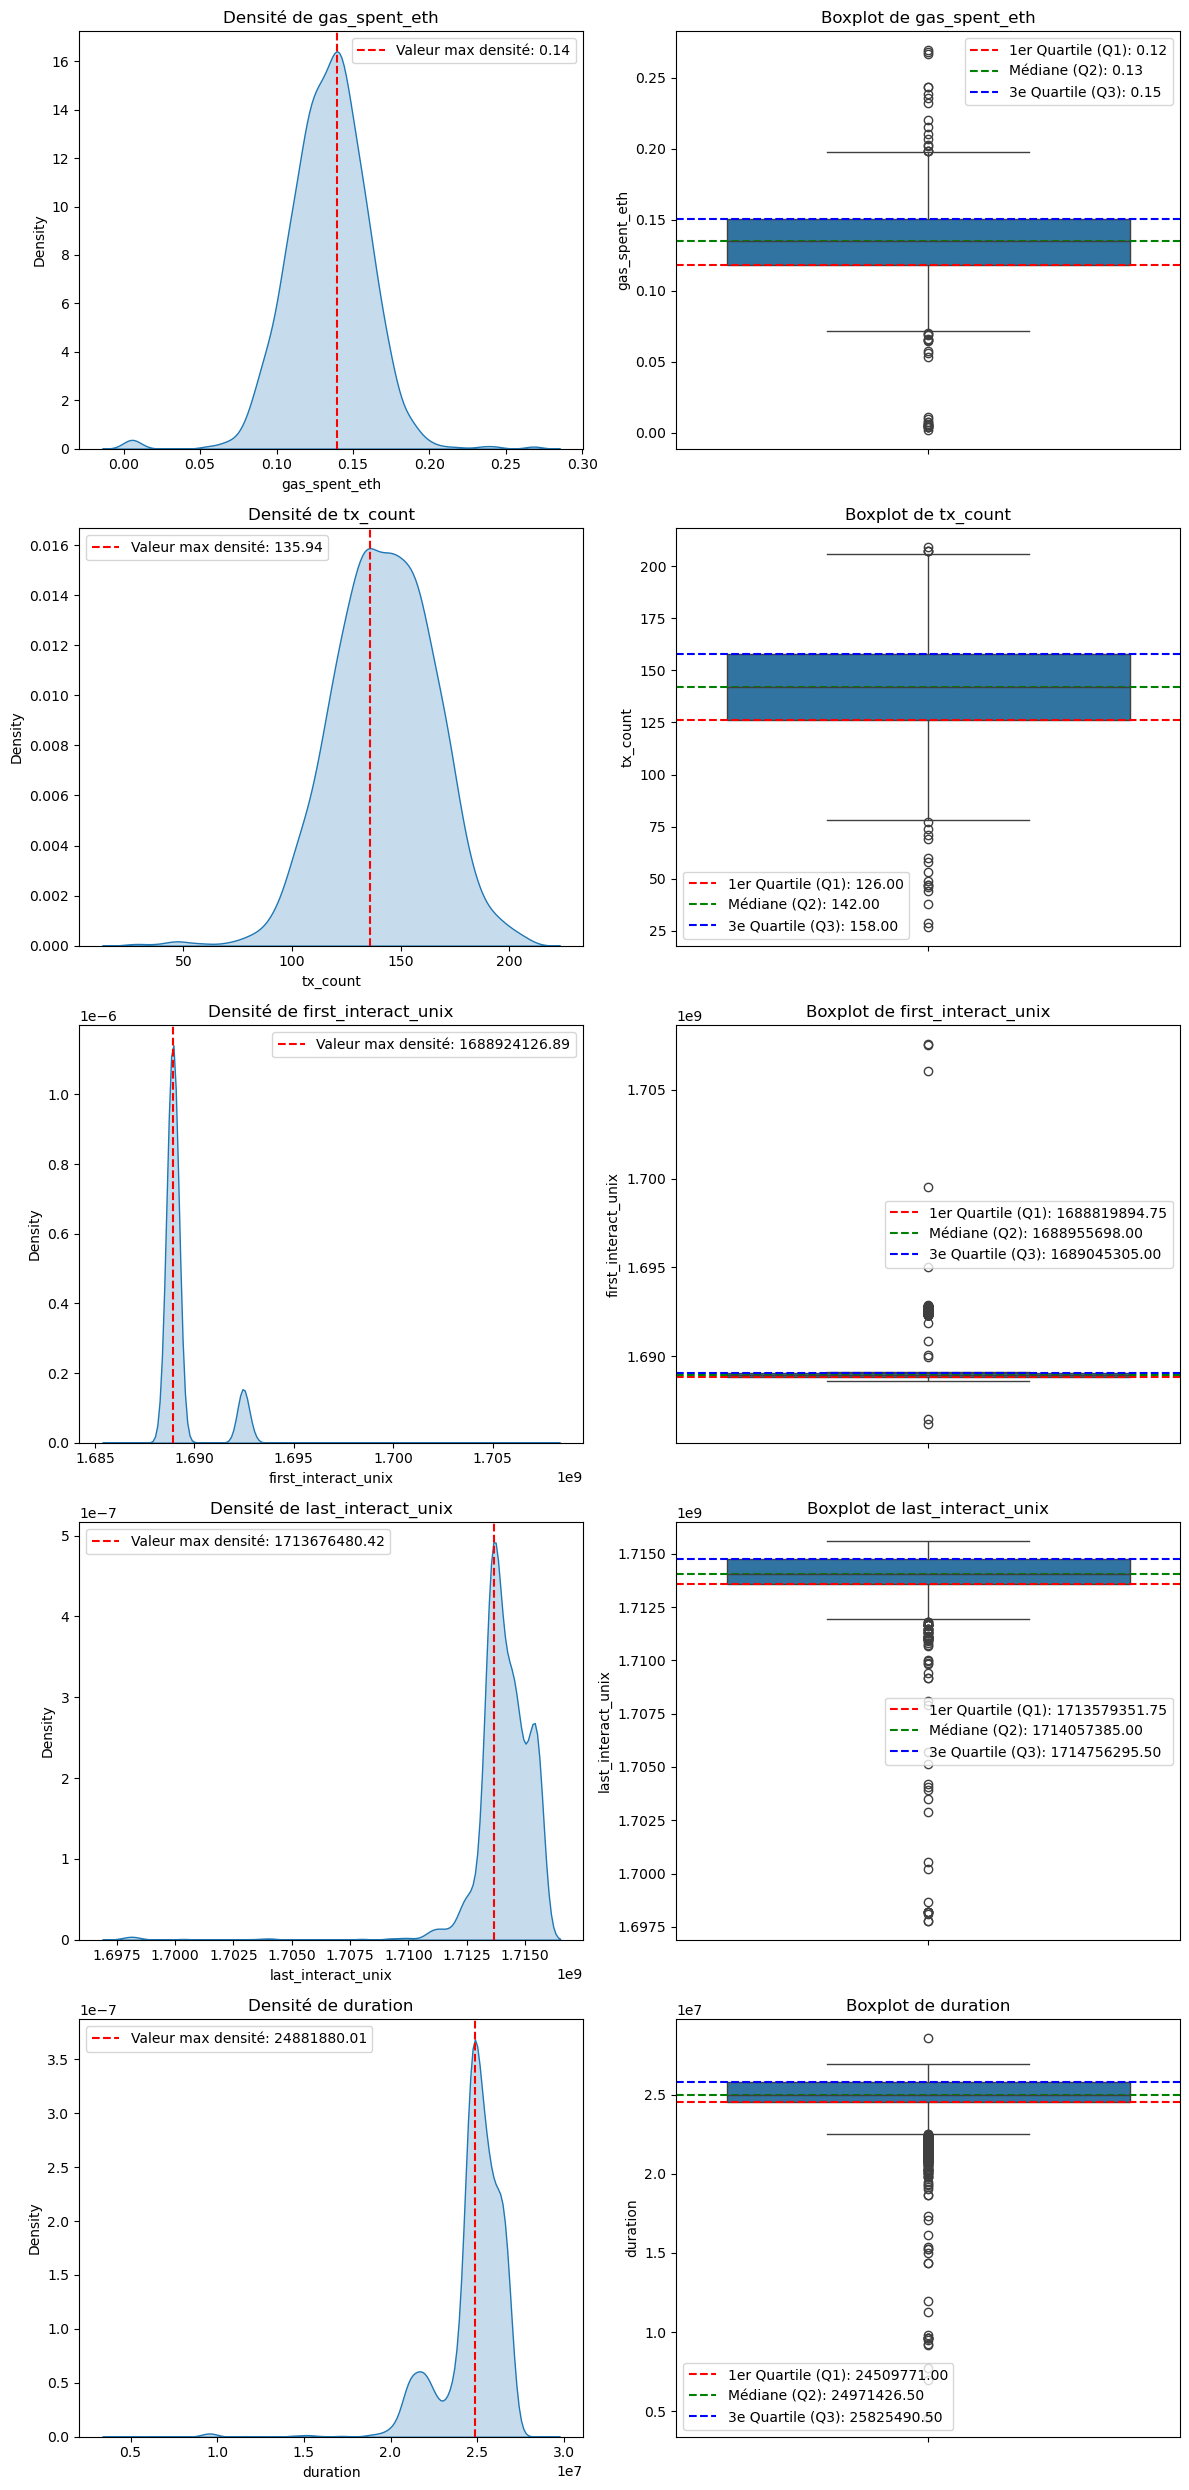

Variable: gas_spent_eth - Valeur avec densité maximale: 0.13953, Densité maximale: 16.42090
Variable: tx_count - Valeur avec densité maximale: 135.94494, Densité maximale: 0.01588
Variable: first_interact_unix - Valeur avec densité maximale: 1688924126.88689, Densité maximale: 0.00000
Variable: last_interact_unix - Valeur avec densité maximale: 1713676480.41742, Densité maximale: 0.00000
Variable: duration - Valeur avec densité maximale: 24881880.00901, Densité maximale: 0.00000


In [ ]:
# Sélectionner les colonnes numériques du DataFrame
numeric_cols = df_sybil.select_dtypes(include=[np.number]).columns

# Définir le nombre de sous-graphes nécessaires
num_vars = len(numeric_cols)
fig, axes = plt.subplots(num_vars, 2, figsize=(12, 5 * num_vars))

# Vérifier si axes est une seule ligne ou plusieurs lignes
if num_vars == 1:
    axes = np.array([axes])

# Dictionnaire pour stocker les valeurs avec densité maximale
max_density_values = {}

# Itérer sur chaque variable numérique et créer les graphiques
for i, col in enumerate(numeric_cols):
    # Tracer la courbe de densité
    sns.kdeplot(df_sybil[col], ax=axes[i, 0], fill=True)
    axes[i, 0].set_title(f'Densité de {col}')

    # Extraire les données de la colonne
    data = df_sybil[col].dropna()  # Retirer les valeurs manquantes

    # Calculer la densité de probabilité avec gaussian_kde
    kde = gaussian_kde(data, bw_method='scott')  # Vous pouvez ajuster bw_method si nécessaire
    x = np.linspace(data.min(), data.max(), 1000)  # Générer une plage de valeurs
    kde_values = kde(x)

    # Trouver l'indice de la densité maximale
    max_density_idx = np.argmax(kde_values)

    # Trouver la valeur correspondante avec la densité maximale
    max_density_value = x[max_density_idx]
    max_density = kde_values[max_density_idx]

    # Ajouter les résultats au dictionnaire
    max_density_values[col] = (max_density_value, max_density)

    # Ajouter une ligne verticale à la valeur avec densité maximale
    axes[i, 0].axvline(max_density_value, color='red', linestyle='--', label=f'Valeur max densité: {max_density_value:.2f}')
    axes[i, 0].legend()

    # Tracer le boxplot
    sns.boxplot(y=df_sybil[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')

    # Calculer les quartiles
    q1 = df_sybil[col].quantile(0.25)
    q2 = df_sybil[col].median()
    q3 = df_sybil[col].quantile(0.75)

    # Ajouter les annotations pour les quartiles
    axes[i, 1].axhline(q1, color='r', linestyle='--', label=f'1er Quartile (Q1): {q1:.2f}')
    axes[i, 1].axhline(q2, color='g', linestyle='--', label=f'Médiane (Q2): {q2:.2f}')
    axes[i, 1].axhline(q3, color='b', linestyle='--', label=f'3e Quartile (Q3): {q3:.2f}')

    # Ajouter la légende
    axes[i, 1].legend()

plt.tight_layout()
plt.show()
# Afficher les valeurs avec densité maximale
for col, (max_value, max_density) in max_density_values.items():
    print(f'Variable: {col} - Valeur avec densité maximale: {max_value:.5f}, Densité maximale: {max_density:.5f}')

- **Les deux premières variables `gas_spent_eth` et `tx_count` semblent suivre une distribution normale, comme en témoignent leurs courbes de densité, parfaitement symétriques autour de la moyenne. Cette symétrie révèle une répartition équilibrée des données de part et d'autre de la moyenne, formant une élégante courbe en cloche avec quelques valeurs aberrantes. En outre, les écarts-types, nettement inférieurs à leurs moyennes respectives, indiquent que les données sont étroitement concentrées autour de la moyenne, ce qui se reflète dans les faibles écarts interquartiles (écart interquartiles = Q3 - Q1) visibles sur les boxplots.**

- **La variable `first_interact_unix` est visuellement caractérisée par deux distributions distinctes : l'une avec un pic dominant correspondant à la valeur de densité maximale, et l'autre avec un pic plus modeste. La plupart des valeurs se situent entre 1.686185e+09 (minimum) et 1.707566e+09 (maximum), ce qui explique l'écart-type relativement faible étant donné l'étendue des valeurs. Cependant, la présence de quelques valeurs aberrantes est soulignée par le boxplot.**

- **La variable `last_interact_unix` affiche une distribution qui, bien que rappelant une loi normale avec un grand pic, s'en écarte quelque peu : on n'observe ni symétrie parfaite ni les queues de distribution typiques. Le boxplot révèle que les valeurs sont principalement concentrées entre 1.697786e+09 et 1.715583e+09, représentant respectivement le minimum et le maximum. Le faible écart interquartiles souligne encore davantage le fait que l'écart-type est relativement bas (1.470549e+06) par rapport à la moyenne (1.714067e+09).**

- **La variable `duration` présente une distribution similaire à celle de `last_interact_unix`, avec deux pics distincts, suggérant l'existence de deux groupes de valeurs prédominantes. Il est intéressant de noter que la valeur la plus probable tourne autour de 24 881 880.01. Visuellement, l'écart interquartiles réduit témoigne d'une forte concentration des valeurs dans cet intervalle, ce qui renforce l'idée d'une distribution étroite des données.**

In [ ]:
df_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,2620.000000,2620.000000,2.620000e+03,2.620000e+03,2.620000e+03
mean,0.133882,141.962595,1.689352e+09,1.714067e+09,2.471490e+07
std,0.026002,23.343201,1.325346e+06,1.470549e+06,1.985502e+06
min,0.002014,27.000000,1.686185e+09,1.697786e+09,4.588585e+06
25%,0.118249,126.000000,1.688820e+09,1.713579e+09,2.450977e+07
50%,0.134776,142.000000,1.688956e+09,1.714057e+09,2.497143e+07
75%,0.150146,158.000000,1.689045e+09,1.714756e+09,2.582549e+07
max,0.269295,209.000000,1.707566e+09,1.715583e+09,2.855194e+07


Ce tableau nous permet d'appuyer les visualisations précédentes et de décrire la manière dont les distributions sont faites par des statistiques descriptives.

#### Analyse univariée des variables qualitatives de df_sybil

# Visualisation 2

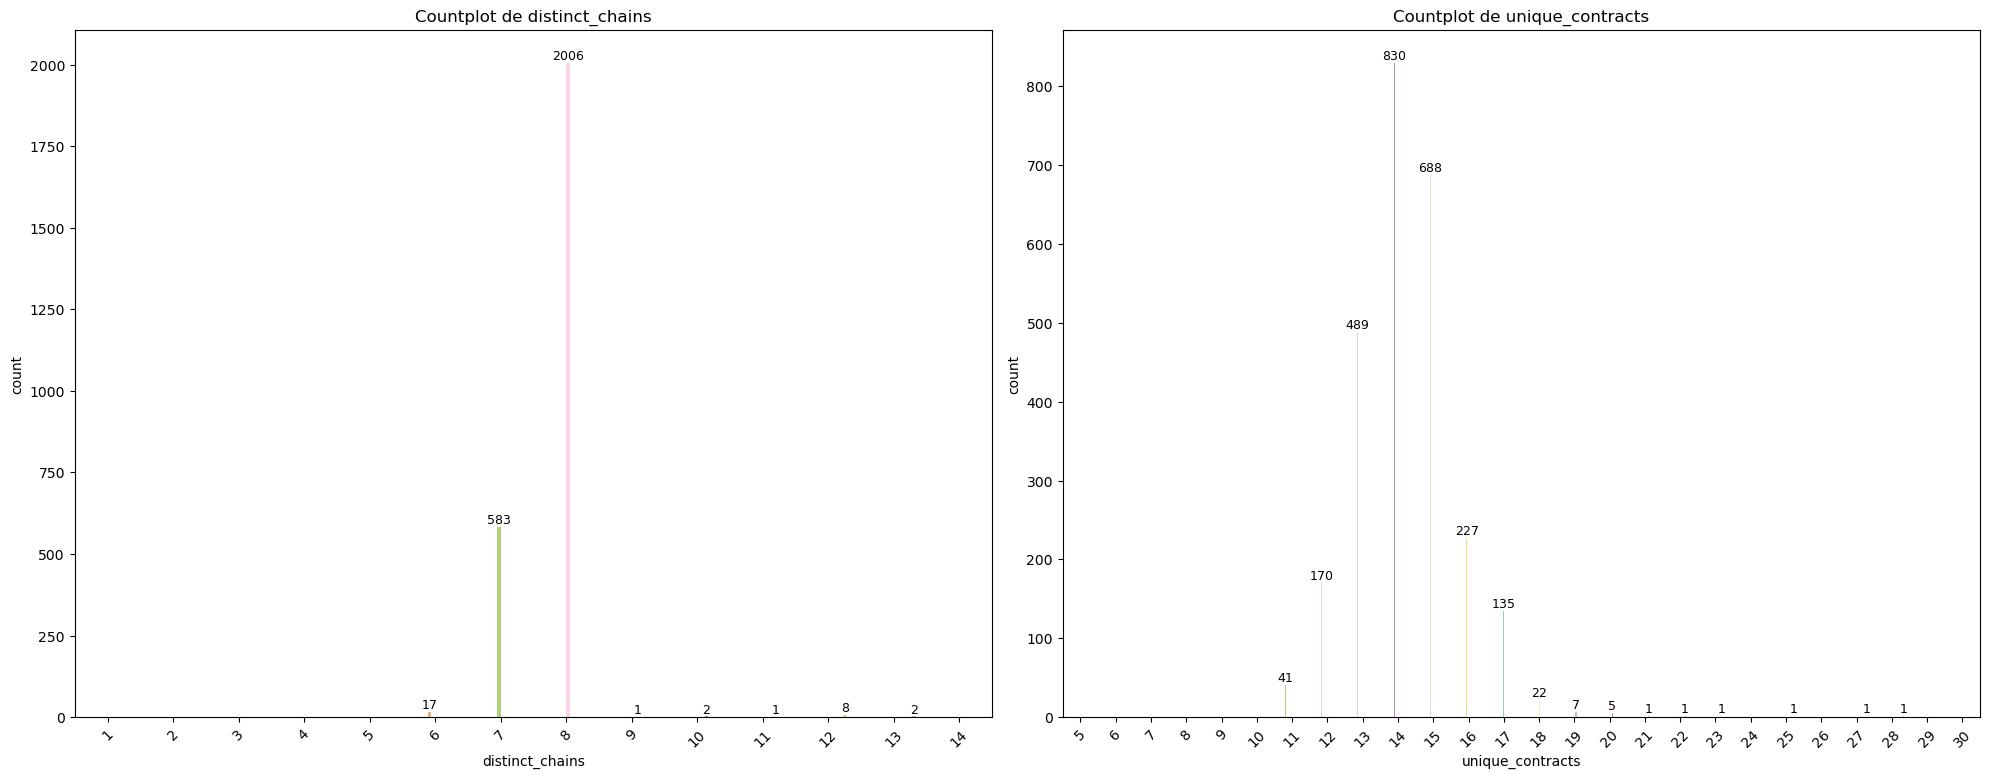

In [ ]:
# Sélectionner les colonnes catégoriques du DataFrame
colonnes_catégoriques = df_sybil.drop(columns='sybil').select_dtypes(include=['category']).columns

# Configuration de la taille de la figure
plt.figure(figsize=(20, 30))

# Boucle pour tracer les countplots
for i, col in enumerate(colonnes_catégoriques, start=1):
    plt.subplot(4, 2, i)  # 4 lignes, 2 colonnes de subplots
    ax = sns.countplot(x=df_sybil[col], hue=df_sybil[col], palette='Set3', legend=False)
    plt.title(f'Countplot de {col}')
    plt.xticks(rotation=45)  # Rotation des étiquettes de l'axe x pour une meilleure lisibilité si nécessaire

    # Ajout des occurrences au-dessus des barres
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 0.5, f'{int(height)}',
                ha='center', va='bottom', fontsize=9, color='black')

# Ajustement automatique de la disposition
plt.tight_layout()

# Affichage de la figure
plt.show()

- **La variable `distinct_chains` prend la majorité de ses valeurs dans l'ensemble {6, 7, 8, 9, 10, 11, 12, 13}. Toutes les adresses Sybil interagissent avec au moins 6 chaînes différentes. Les modalités 7 et 8 couvrent près de 98 % des occurrences**.
- **Pour la variable `unique_contracts`, 99 % des valeurs appartiennent à l'ensemble {11, 12, 13, 14, 15, 16, 17, 18}**.

In [ ]:
# Statistiques descriptive des variables catégoriques
df_sybil.drop(columns='sybil').describe(include='category')

,distinct_chains,unique_contracts
count,2620,2620
unique,8,16
top,8,14
freq,2006,830


### Analyse univariée des adresses df_non_sybil

In [ ]:
df_non_sybil.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367818 entries, 0 to 370437
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   address              367818 non-null  object  
 1   distinct_chains      367818 non-null  category
 2   chains_list          367818 non-null  object  
 3   gas_spent_eth        367818 non-null  float64 
 4   tx_count             367818 non-null  int64   
 5   unique_contracts     367818 non-null  category
 6   sybil                367818 non-null  category
 7   first_interact_unix  367818 non-null  float64 
 8   last_interact_unix   367818 non-null  float64 
 9   duration             367818 non-null  float64 
dtypes: category(3), float64(4), int64(1), object(2)
memory usage: 23.5+ MB


# Visualisation 3

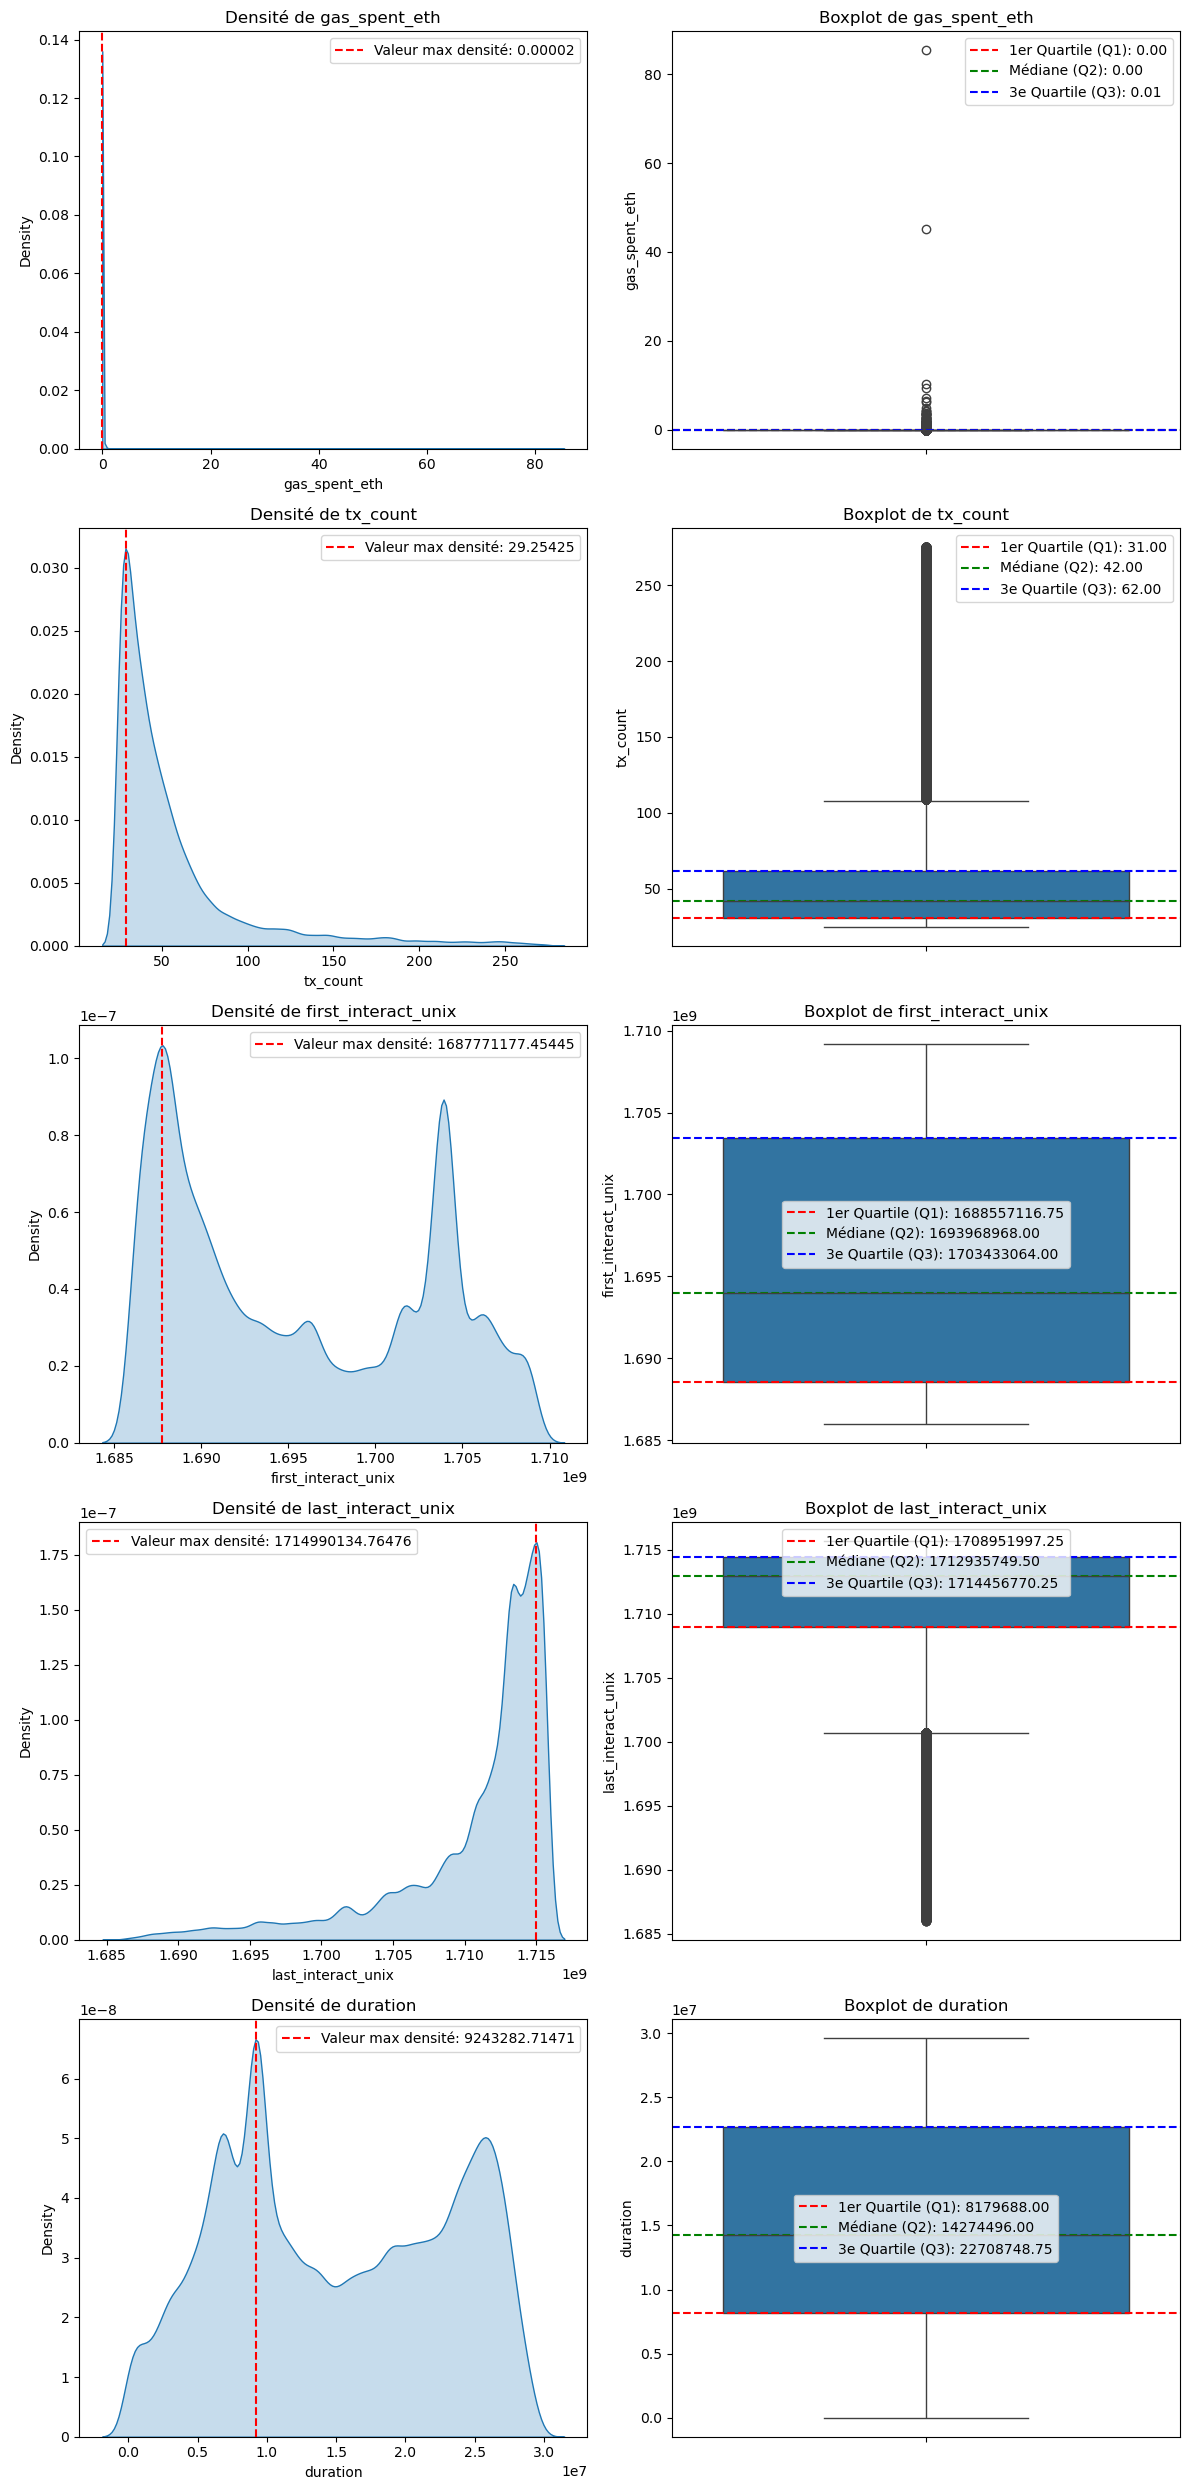

Variable: gas_spent_eth - Valeur avec densité maximale: 0.00002, Densité maximale: 27.04421
Variable: tx_count - Valeur avec densité maximale: 29.25425, Densité maximale: 0.03158
Variable: first_interact_unix - Valeur avec densité maximale: 1687771177.45445, Densité maximale: 0.00000
Variable: last_interact_unix - Valeur avec densité maximale: 1714990134.76476, Densité maximale: 0.00000
Variable: duration - Valeur avec densité maximale: 9243282.71471, Densité maximale: 0.00000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Sélectionner les colonnes numériques du DataFrame
numeric_cols = df_non_sybil.select_dtypes(include=[np.number]).columns

# Définir le nombre de sous-graphes nécessaires
num_vars = len(numeric_cols)
fig, axes = plt.subplots(num_vars, 2, figsize=(12, 5 * num_vars))

# Vérifier si axes est une seule ligne ou plusieurs lignes
if num_vars == 1:
    axes = np.array([axes])

# Dictionnaire pour stocker les valeurs avec densité maximale
max_density_values = {}

# Itérer sur chaque variable numérique et créer les graphiques
for i, col in enumerate(numeric_cols):
    # Tracer la courbe de densité
    sns.kdeplot(df_non_sybil[col], ax=axes[i, 0], fill=True)
    axes[i, 0].set_title(f'Densité de {col}')

    # Extraire les données de la colonne
    data = df_non_sybil[col].dropna()  # Retirer les valeurs manquantes

    # Calculer la densité de probabilité avec gaussian_kde
    kde = gaussian_kde(data, bw_method='scott')  # Vous pouvez ajuster bw_method si nécessaire
    x = np.linspace(data.min(), data.max(), 1000)  # Générer une plage de valeurs
    kde_values = kde(x)

    # Trouver l'indice de la densité maximale
    max_density_idx = np.argmax(kde_values)

    # Trouver la valeur correspondante avec la densité maximale
    max_density_value = x[max_density_idx]
    max_density = kde_values[max_density_idx]

    # Ajouter les résultats au dictionnaire avec une précision de 10^-5
    max_density_values[col] = (round(max_density_value, 5), round(max_density, 5))

    # Ajouter une ligne verticale à la valeur avec densité maximale
    axes[i, 0].axvline(max_density_value, color='red', linestyle='--', label=f'Valeur max densité: {max_density_value:.5f}')
    axes[i, 0].legend()

    # Tracer le boxplot
    sns.boxplot(y=df_non_sybil[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')

    # Calculer les quartiles
    q1 = df_non_sybil[col].quantile(0.25)
    q2 = df_non_sybil[col].median()
    q3 = df_non_sybil[col].quantile(0.75)

    # Ajouter les annotations pour les quartiles
    axes[i, 1].axhline(q1, color='r', linestyle='--', label=f'1er Quartile (Q1): {q1:.2f}')
    axes[i, 1].axhline(q2, color='g', linestyle='--', label=f'Médiane (Q2): {q2:.2f}')
    axes[i, 1].axhline(q3, color='b', linestyle='--', label=f'3e Quartile (Q3): {q3:.2f}')

    # Ajouter la légende
    axes[i, 1].legend()

plt.tight_layout()
plt.show()
# Afficher les valeurs avec densité maximale
for col, (max_value, max_density) in max_density_values.items():
    print(f'Variable: {col} - Valeur avec densité maximale: {max_value:.5f}, Densité maximale: {max_density:.5f}')

- **La courbe de densité de la variable `gas_spent_eth` n'est pas très lisible en raison de l'échelle. Le maximum de cette variable est de 85.383263, ce qui implique une échelle des valeurs de gaz ( axe des abscisses) atypique où visuellement, toutes les valeurs semblent se confondre avec 0 en raison de cette valeur extrême. Le boxplot nous montre un écart inter-quartile extremement petit visuellement, justifiant la concentrations des valeurs autour de 0. Cependant l'écart-type numériquement est bien plus élevée que la moyenne : ce dernier phénomène est due dues aux valeurs aberrantes.**
  
- **Pour la variable `tx_count`, la courbe de densité montre une distribution normale approximative sur l'intervalle [25, 100], suivie par une distribution uniforme sur l'intervalle [100, 275]. La majorité des valeurs se situent dans l'intervalle [31, 62], correspondant au premier et au troisième quartile (Q1 et Q3).**

- **Contrairement au jeu de données Sybil, cette variable montre une distribution hétérogène avec une variance plus élevée. Environ 75 % des valeurs sont situées dans l'intervalle [1.688 × 10^9; 1.709165 × 10^9].**

- **La variable `last_interact_unix` semble avoir l'allure d'une loi exponentielle négative, avec des valeurs aberrantes étant toutes inférieures à la moyenne moins 1,5 fois l'intervalle interquartile (IQR).**

- **La variable `duration` semble être distribuée de manière hétérogène avec deux pics principaux : l'un autour de 0.8 × 10^7 et l'autre autour de 2.6 × 10^7. Ces deux plages correspondent aux endroits où la majorité des valeurs sont concentrées.**


In [ ]:
df_non_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,367818.000000,367818.000000,3.678180e+05,3.678180e+05,3.678180e+05
mean,0.008072,56.304678,1.695598e+09,1.710589e+09,1.499127e+07
std,0.165554,41.746199,7.288820e+06,5.772642e+06,8.114226e+06
min,0.000024,25.000000,1.686010e+09,1.686015e+09,1.600000e+01
25%,0.002315,31.000000,1.688557e+09,1.708952e+09,8.179688e+06
50%,0.003671,42.000000,1.693969e+09,1.712936e+09,1.427450e+07
75%,0.006463,62.000000,1.703433e+09,1.714457e+09,2.270875e+07
max,85.383263,275.000000,1.709165e+09,1.715643e+09,2.959624e+07


# Visualisation 4

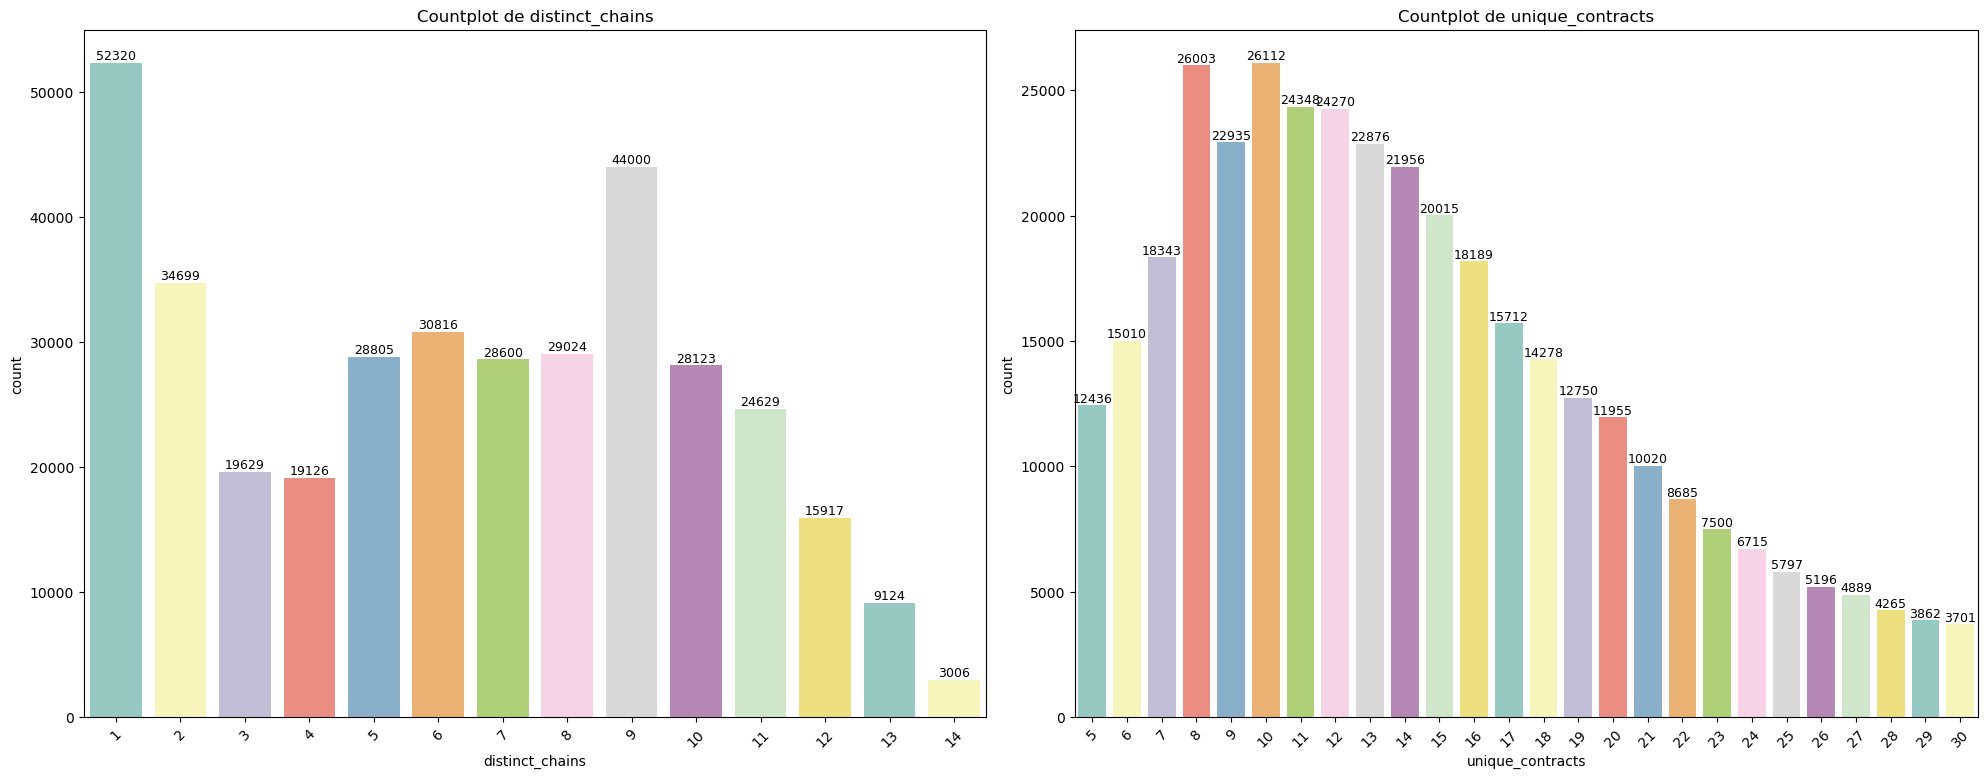

In [ ]:
# Sélectionner les colonnes catégoriques du DataFrame
colonnes_catégoriques = df_sybil.drop(columns='sybil').select_dtypes(include=['category']).columns

# Configuration de la taille de la figure
plt.figure(figsize=(20, 30))

# Boucle pour tracer les countplots
for i, col in enumerate(colonnes_catégoriques, start=1):
    plt.subplot(4, 2, i)  # 4 lignes, 2 colonnes de subplots
    ax = sns.countplot(x=df_non_sybil[col], hue=df_non_sybil[col], palette='Set3', legend=False)
    plt.title(f'Countplot de {col}')
    plt.xticks(rotation=45)  # Rotation des étiquettes de l'axe x pour une meilleure lisibilité si nécessaire

    # Ajout des occurrences au-dessus des barres
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 0.5, f'{int(height)}',
                ha='center', va='bottom', fontsize=9, color='black')

# Ajustement automatique de la disposition
plt.tight_layout()

# Affichage de la figure
plt.show()

- Contrairement au cas **sybil**, une adresse peut interagir avec **1** chaîne ou bien **14** : toutes les valeurs sont prises. Les 3 premières avec le plus d'occurrences sont **1**, **9**, et **2** qui couvrent **35%** des valeurs prises.
- Pour la variable **unique_contracts**, on peut visualiser une distribution de **Poisson**. Contrairement au cas **sybil**, l'ensemble des valeurs prises est dans l'intervalle {5, 6, 7, ..., 30}. Les valeurs **8, 9, 10, 11, 12, 13, 14**, et **15** ont plus de **20,000** occurrences et couvrent **51,1%** du nombre d'observations.

In [ ]:
df_non_sybil.describe(include='category')

,distinct_chains,unique_contracts,sybil
count,367818,367818,367818
unique,14,26,1
top,1,10,0
freq,52320,26112,367818


## Étude de la variable chains_list

Pour la variable 'chains_list, chacune des observations étant une liste de chaînes. Il serait intéressant de construire un histogramme des fréquences en distinguant les valeurs selon qu'elles sont associées à des entités sybils ou non. Cela permettrait d'identifier quelles chaînes sont plus fréquentes chez les sybils par rapport aux non-sybils.

In [ ]:
df1['chains_list']

0                                                [arbitrum]
1                                         [goerli arbitrum]
2                                   [bnb ethereum arbitrum]
3                     [base optimism arbitrum ethereum bnb]
4         [base bnb arbitrum goerli ethereum zksync poly...
                                ...                        
370433      [optimism ethereum polygon arbitrum zksync bnb]
370434                                           [arbitrum]
370435                                           [arbitrum]
370436     [bnb avalanche_c polygon optimism arbitrum base]
370437    [polygon bnb base zksync optimism goerli ether...
Name: chains_list, Length: 370438, dtype: object

Voici l'aspect des valeurs : des listes de noms de chaînes, sans guillemets. Voyons si cette variable créee des différences chez les adresses sybils ou non ?

Dans la suite, nous allons inspecter les occurences de chaines avec les restrictions suivantes :
- Étape 1 : Sans restriction
- Étape 2 : Si 'distinct_chains'== 7
- Étape 3 : Si 'distinct_chains'== 8
- Étape 4 : Si 'distinct_chains' est à valeurs dans {6,9,10,11,12,13}
- Étape 5 : Si 'distinct_chains' est à valeurs dans {6,7,8,9,10,11,12,13}

In [ ]:
# Fonction pour transformer une chaîne en liste de mots entre guillemets
def transform_chain(chain):
    # Enlever les crochets
    chain = chain.strip('[]')
    # Séparer les mots par des espaces
    words = chain.split()
    # Ajouter des guillemets autour de chaque mot
    words = [f'"{word}"' for word in words]
    return words

# Appliquer la transformation à chaque élément de la colonne 'chains_list'
df1['chains_list'] = df1['chains_list'].apply(transform_chain)

In [ ]:
%pwd

'/Users/dylan/10000h/DATA/Python/Ipynb/Notebooks_de_datasets'

In [ ]:
import pandas as pd

# Chemin où vous souhaitez enregistrer le fichier CSV
path = '/Users/dylan/10000h/DATA/Python/JDD/'

# Supposons que df1 est déjà créé ou chargé dans votre script

# Enregistrer le DataFrame df1 sous le nom "all_wallet_maj.csv" dans le chemin spécifié
df1.to_csv(path + "all_wallet_maj.csv", index=False)


## Étude 1

# Visualisation 5

In [ ]:
# Initialiser des compteurs pour sybils et non-sybils
sybil_counter = Counter()
non_sybil_counter = Counter()

# Parcourir chaque liste dans la colonne 'chains_list' et mettre à jour les compteurs en fonction de 'is_sybil'
for chains, is_sybil in zip(df1['chains_list'], df1['sybil']):
    if is_sybil:
        sybil_counter.update(chains)
    else:
        non_sybil_counter.update(chains)

# Convertir les Counters en DataFrames
sybil_freq_df = pd.DataFrame.from_dict(sybil_counter, orient='index', columns=['Frequency']).reset_index()
sybil_freq_df.columns = ['Chain', 'Frequency']
sybil_freq_df = sybil_freq_df.sort_values(by='Frequency', ascending=False)

non_sybil_freq_df = pd.DataFrame.from_dict(non_sybil_counter, orient='index', columns=['Frequency']).reset_index()
non_sybil_freq_df.columns = ['Chain', 'Frequency']
non_sybil_freq_df = non_sybil_freq_df.sort_values(by='Frequency', ascending=False)

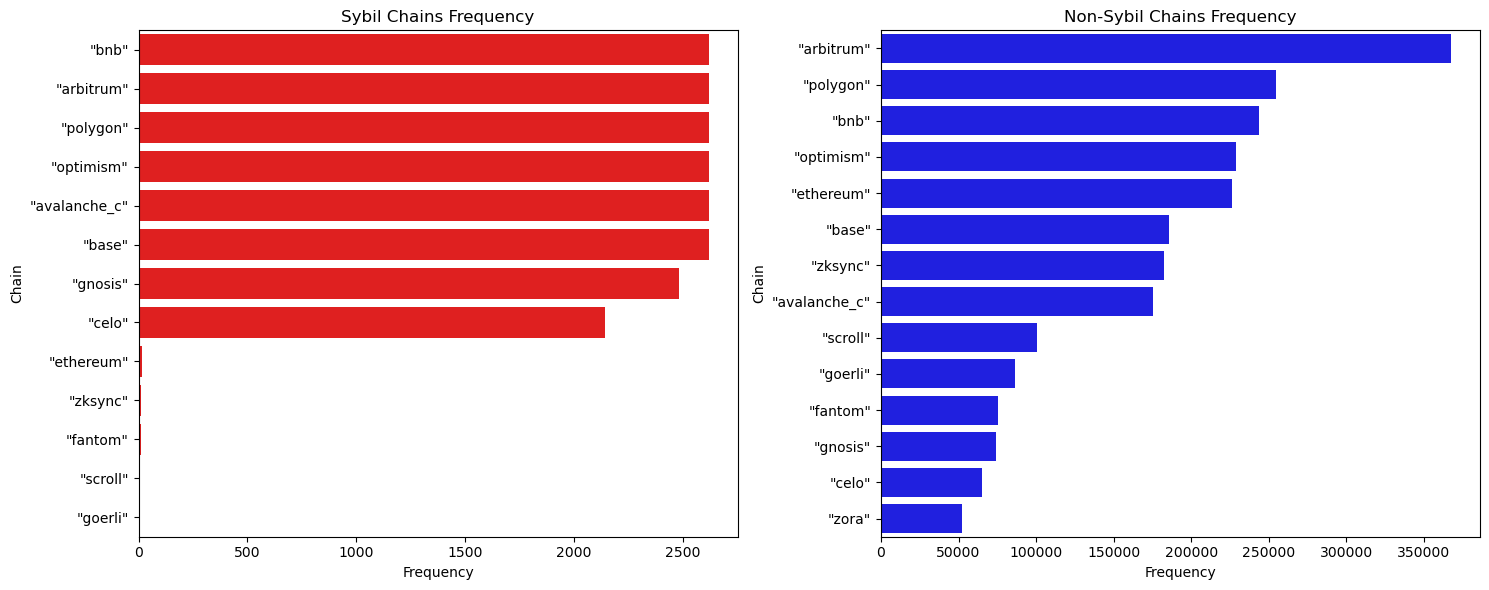

In [ ]:
# Créer une figure avec deux sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualisation pour sybil avec couleur unique
sns.barplot(x='Frequency', y='Chain', data=sybil_freq_df, color='red', ax=axes[0])
axes[0].set_title('Sybil Chains Frequency')

# Visualisation pour non-sybil avec couleur unique
sns.barplot(x='Frequency', y='Chain', data=non_sybil_freq_df, color='blue', ax=axes[1])
axes[1].set_title('Non-Sybil Chains Frequency')

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [ ]:
# Ajouter les pourcentages au DataFrame des sybils
sybil_freq_df['Percentage'] = (sybil_freq_df['Frequency'] / sybil_freq_df['Frequency'].sum()) * 100

# Ajouter les pourcentages au DataFrame des non-sybils
non_sybil_freq_df['Percentage'] = (non_sybil_freq_df['Frequency'] / non_sybil_freq_df['Frequency'].sum()) * 100

# Affichage des résultats
print("Fréquence et pourcentage des chaînes pour les adresses sybils :")
print(sybil_freq_df)
print("\nFréquence et pourcentage des chaînes pour les adresses non-sybils :")
print(non_sybil_freq_df)

Fréquence et pourcentage des chaînes pour les adresses sybils :
            Chain  Frequency  Percentage
5           "bnb"       2620   12.847546
7      "arbitrum"       2620   12.847546
2       "polygon"       2619   12.842642
3      "optimism"       2619   12.842642
6   "avalanche_c"       2619   12.842642
1          "base"       2618   12.837738
0        "gnosis"       2481   12.165939
4          "celo"       2144   10.513411
8      "ethereum"         14    0.068651
9        "zksync"         13    0.063747
11       "fantom"         12    0.058844
12       "scroll"          9    0.044133
10       "goerli"          5    0.024518

Fréquence et pourcentage des chaînes pour les adresses non-sybils :
            Chain  Frequency  Percentage
0      "arbitrum"     367818   15.866048
7       "polygon"     254716   10.987326
2           "bnb"     243476   10.502482
5      "optimism"     228573    9.859632
3      "ethereum"     226081    9.752139
4          "base"     185611    8.006441
6     

- **Les adresses sybils** interagissent considérablement avec au plus **8 chaînes** : **'bnb'**, **'arbitrum'**, **'polygon'**, **'optimism'**, **'avalanche_c'**, **'base'**, **'gnosis'** et **'celo'**, qui sont aussi utilisées par les adresses non-sybils. Par contre, les adresses sybils n'ont pas grandement interagi avec les chaînes **'ethereum'**, **'zksync'**, **'fantom'**, **'scroll'** et **'goerli'**.

### Étude 2 : Si 'distinct_chains' == 7

# Visualisation 6

In [ ]:
# Initialiser des compteurs pour sybils et non-sybils
sybil_counter = Counter()
non_sybil_counter = Counter()

# Parcourir chaque liste dans la colonne 'chains_list' et la variable catégorielle 'distinct_chains'
for chains, is_sybil, distinct_chains in zip(df1['chains_list'], df1['sybil'], df1['distinct_chains']):
    if distinct_chains == 7:  # S'assurer que la condition est satisfaite pour une catégorie
        if is_sybil:
            sybil_counter.update(chains)
        else:
            non_sybil_counter.update(chains)

# Convertir les Counters en DataFrames
sybil_freq_df = pd.DataFrame.from_dict(sybil_counter, orient='index', columns=['Frequency']).reset_index()
sybil_freq_df.columns = ['Chain', 'Frequency']
sybil_freq_df['Percentage'] = (sybil_freq_df['Frequency'] / sybil_freq_df['Frequency'].sum()) * 100
sybil_freq_df = sybil_freq_df.sort_values(by='Frequency', ascending=False)

non_sybil_freq_df = pd.DataFrame.from_dict(non_sybil_counter, orient='index', columns=['Frequency']).reset_index()
non_sybil_freq_df.columns = ['Chain', 'Frequency']
non_sybil_freq_df['Percentage'] = (non_sybil_freq_df['Frequency'] / non_sybil_freq_df['Frequency'].sum()) * 100
non_sybil_freq_df = non_sybil_freq_df.sort_values(by='Frequency', ascending=False)

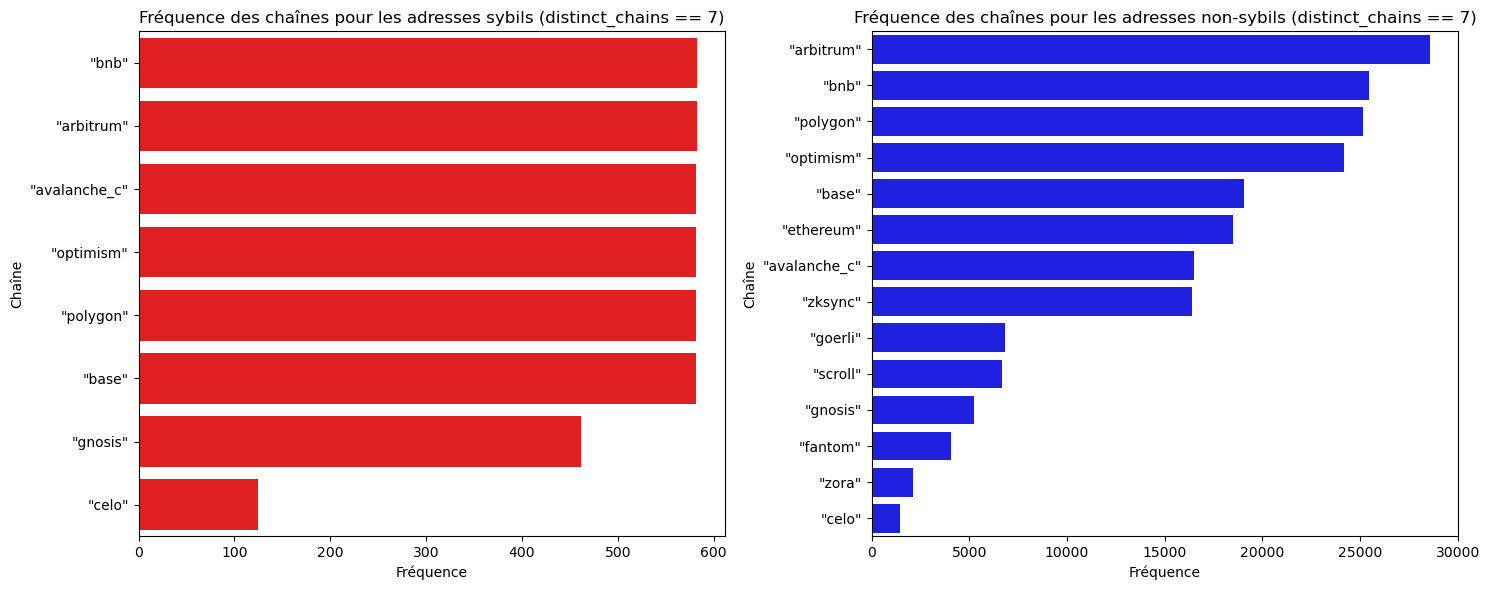

In [ ]:
# Créer une figure avec deux sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualisation pour les adresses sybils avec couleur rouge
sns.barplot(x='Frequency', y='Chain', data=sybil_freq_df, color='red', ax=axes[0])
axes[0].set_title('Fréquence des chaînes pour les adresses sybils (distinct_chains == 7)')
axes[0].set_xlabel('Fréquence')
axes[0].set_ylabel('Chaîne')

# Visualisation pour les adresses non-sybils avec couleur bleue
sns.barplot(x='Frequency', y='Chain', data=non_sybil_freq_df, color='blue', ax=axes[1])
axes[1].set_title('Fréquence des chaînes pour les adresses non-sybils (distinct_chains == 7)')
axes[1].set_xlabel('Fréquence')
axes[1].set_ylabel('Chaîne')

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [ ]:
# Afficher les résultats
print("Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 7) :")
print(sybil_freq_df)
print("\nFréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 7) :")
print(non_sybil_freq_df)

Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 7) :
           Chain  Frequency  Percentage
1          "bnb"        583   14.285714
5     "arbitrum"        583   14.285714
0  "avalanche_c"        582   14.261210
2     "optimism"        582   14.261210
3      "polygon"        582   14.261210
6         "base"        582   14.261210
4       "gnosis"        462   11.320755
7         "celo"        125    3.062975

Fréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 7) :
            Chain  Frequency  Percentage
4      "arbitrum"      28600   14.285714
8           "bnb"      25445   12.709790
6       "polygon"      25146   12.560440
0      "optimism"      24167   12.071429
2          "base"      19067    9.523976
1      "ethereum"      18482    9.231768
7   "avalanche_c"      16522    8.252747
5        "zksync"      16389    8.186314
3        "goerli"       6844    3.418581
11       "scroll"       6679    3.336164
9        "

Cette restriction ajoutée nous informe que ce type d'adresse sybil interagit seulement avec au plus 8 chaines : bnb, arbitrum, avalanche_c, optimism, polygon, base, gnosis, celo. Au contraire, elle n'interagit pas avec ethereum, zora, fantom, "scroll, "goerli", zksync : ce qui fait 6 chaines.

### Étude 3 : Si 'distinct_chains'== 8

# Visualisation 7

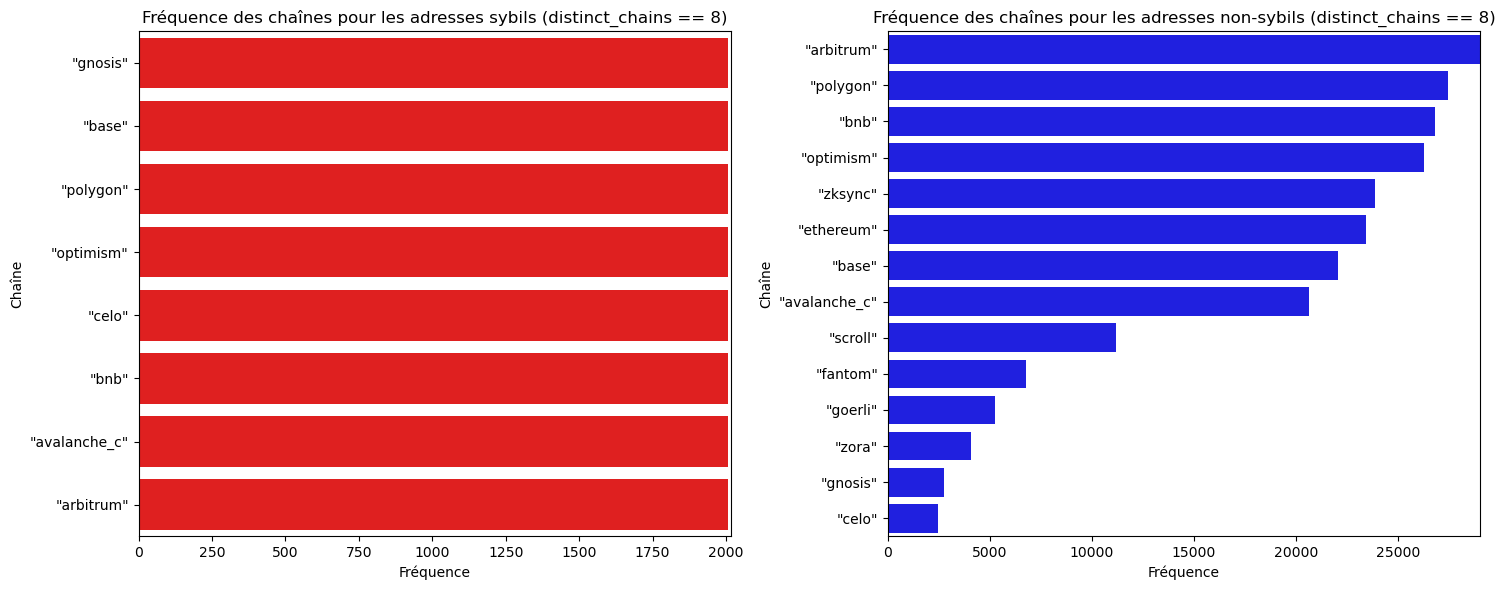

In [ ]:
# Initialiser des compteurs pour sybils et non-sybils
sybil_counter = Counter()
non_sybil_counter = Counter()

# Parcourir chaque liste dans la colonne 'chains_list' et la variable catégorielle 'distinct_chains'
for chains, is_sybil, distinct_chains in zip(df1['chains_list'], df1['sybil'], df1['distinct_chains']):
    if distinct_chains == 8:  # S'assurer que la condition est satisfaite pour une catégorie
        if is_sybil:
            sybil_counter.update(chains)
        else:
            non_sybil_counter.update(chains)

# Convertir les Counters en DataFrames
sybil_freq_df = pd.DataFrame.from_dict(sybil_counter, orient='index', columns=['Frequency']).reset_index()
sybil_freq_df.columns = ['Chain', 'Frequency']
sybil_freq_df['Percentage'] = (sybil_freq_df['Frequency'] / sybil_freq_df['Frequency'].sum()) * 100
sybil_freq_df = sybil_freq_df.sort_values(by='Frequency', ascending=False)

non_sybil_freq_df = pd.DataFrame.from_dict(non_sybil_counter, orient='index', columns=['Frequency']).reset_index()
non_sybil_freq_df.columns = ['Chain', 'Frequency']
non_sybil_freq_df['Percentage'] = (non_sybil_freq_df['Frequency'] / non_sybil_freq_df['Frequency'].sum()) * 100
non_sybil_freq_df = non_sybil_freq_df.sort_values(by='Frequency', ascending=False)
# Créer une figure avec deux sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualisation pour les adresses sybils avec couleur rouge
sns.barplot(x='Frequency', y='Chain', data=sybil_freq_df, color='red', ax=axes[0])
axes[0].set_title('Fréquence des chaînes pour les adresses sybils (distinct_chains == 8)')
axes[0].set_xlabel('Fréquence')
axes[0].set_ylabel('Chaîne')

# Ajuster l'échelle de l'axe y pour correspondre aux valeurs observées
axes[0].set_xlim(0, sybil_freq_df['Frequency'].max() + 10)

# Visualisation pour les adresses non-sybils avec couleur bleue
sns.barplot(x='Frequency', y='Chain', data=non_sybil_freq_df, color='blue', ax=axes[1])
axes[1].set_title('Fréquence des chaînes pour les adresses non-sybils (distinct_chains == 8)')
axes[1].set_xlabel('Fréquence')
axes[1].set_ylabel('Chaîne')

# Ajuster l'échelle de l'axe y pour correspondre aux valeurs observées
axes[1].set_xlim(0, non_sybil_freq_df['Frequency'].max() + 10)

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [ ]:
# Vérifier les données
print(sybil_freq_df)
print(non_sybil_freq_df)

           Chain  Frequency  Percentage
0       "gnosis"       2006        12.5
1         "base"       2006        12.5
2      "polygon"       2006        12.5
3     "optimism"       2006        12.5
4         "celo"       2006        12.5
5          "bnb"       2006        12.5
6  "avalanche_c"       2006        12.5
7     "arbitrum"       2006        12.5
            Chain  Frequency  Percentage
2      "arbitrum"      29024   12.500000
6       "polygon"      27476   11.833310
1           "bnb"      26851   11.564137
7      "optimism"      26286   11.320803
5        "zksync"      23905   10.295359
4      "ethereum"      23453   10.100693
0          "base"      22082    9.510233
10  "avalanche_c"      20641    8.889626
8        "scroll"      11170    4.810674
11       "fantom"       6753    2.908369
3        "goerli"       5265    2.267520
9          "zora"       4068    1.751998
12       "gnosis"       2770    1.192978
13         "celo"       2448    1.054300


Interprétation : Cette restriction ajoutée nous informe que ce type d'adresse sybil interagit seulement avec au plus 8 chaines : bnb, arbitrum, avalanche_c, optimism, polygon, base, gnosis, celo. Au contraire, elle n'interagit pas avec ethereum, zora, fantom, "scroll, "goerli", zksync : ce qui fait 6 chaines. Plus précisément, toutes les adresses sybils avec cette condition interagissent avec les mêmes. il y'a donc une 1 combinaison de chaines distinctes pour les 2006 adresses sybils.

### Étude 4 : Si 'distinct_chains' est à valeurs dans {6,9,10,11,12,13}

# Visualisation 8

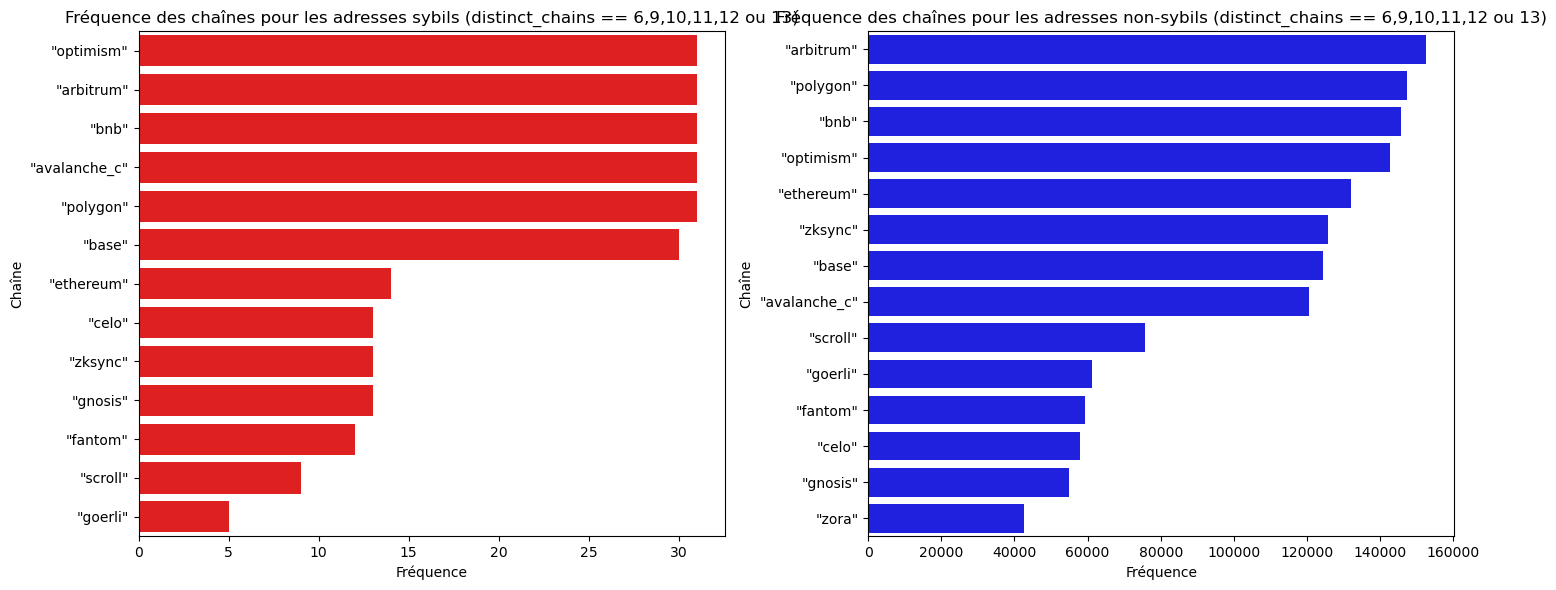

In [ ]:
# Initialiser des compteurs pour sybils et non-sybils
sybil_counter = Counter()
non_sybil_counter = Counter()

# Filtrer les lignes où distinct_chains est égal à 7 ou 8
filtered_df = df1[df1['distinct_chains'].isin([6,9,10,11,12,13])]

# Parcourir chaque liste dans la colonne 'chains_list' et la variable catégorielle 'sybil'
for chains, is_sybil in zip(filtered_df['chains_list'], filtered_df['sybil']):
    if is_sybil:
        sybil_counter.update(chains)
    else:
        non_sybil_counter.update(chains)

# Convertir les Counters en DataFrames
sybil_freq_df = pd.DataFrame.from_dict(sybil_counter, orient='index', columns=['Frequency']).reset_index()
sybil_freq_df.columns = ['Chain', 'Frequency']
sybil_freq_df['Percentage'] = (sybil_freq_df['Frequency'] / sybil_freq_df['Frequency'].sum()) * 100
sybil_freq_df = sybil_freq_df.sort_values(by='Frequency', ascending=False)

non_sybil_freq_df = pd.DataFrame.from_dict(non_sybil_counter, orient='index', columns=['Frequency']).reset_index()
non_sybil_freq_df.columns = ['Chain', 'Frequency']
non_sybil_freq_df['Percentage'] = (non_sybil_freq_df['Frequency'] / non_sybil_freq_df['Frequency'].sum()) * 100
non_sybil_freq_df = non_sybil_freq_df.sort_values(by='Frequency', ascending=False)

# Créer une figure avec deux sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualisation pour les adresses sybils avec couleur rouge
sns.barplot(x='Frequency', y='Chain', data=sybil_freq_df, color='red', ax=axes[0])
axes[0].set_title('Fréquence des chaînes pour les adresses sybils (distinct_chains == 6,9,10,11,12 ou 13)')
axes[0].set_xlabel('Fréquence')
axes[0].set_ylabel('Chaîne')

# Visualisation pour les adresses non-sybils avec couleur bleue
sns.barplot(x='Frequency', y='Chain', data=non_sybil_freq_df, color='blue', ax=axes[1])
axes[1].set_title('Fréquence des chaînes pour les adresses non-sybils (distinct_chains == 6,9,10,11,12 ou 13)')
axes[1].set_xlabel('Fréquence')
axes[1].set_ylabel('Chaîne')

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [ ]:
# Afficher les résultats
print("Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 6,9,10,11,12,13) :")
print(sybil_freq_df)
print("\nFréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 6,9,10,11,12,13) :")
print(non_sybil_freq_df)

Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 6,9,10,11,12,13) :
            Chain  Frequency  Percentage
0      "optimism"         31   11.742424
1      "arbitrum"         31   11.742424
2           "bnb"         31   11.742424
3   "avalanche_c"         31   11.742424
4       "polygon"         31   11.742424
5          "base"         30   11.363636
7      "ethereum"         14    5.303030
6          "celo"         13    4.924242
8        "zksync"         13    4.924242
11       "gnosis"         13    4.924242
10       "fantom"         12    4.545455
12       "scroll"          9    3.409091
9        "goerli"          5    1.893939

Fréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 6,9,10,11,12,13) :
            Chain  Frequency  Percentage
4      "arbitrum"     152609   10.578299
0       "polygon"     147461   10.221459
5           "bnb"     145763   10.103760
1      "optimism"     142643    9.887493
2      "ethere

Cette étude nous dit que les adresses, sybils à valeurs dans {6,9,10,11,12,13} n'interagissent pas avec zora.

### Étude 5 : Si 'distinct_chains' est à valeurs dans {6,7,8,9,10,11,12,13}

# Visualisation 9

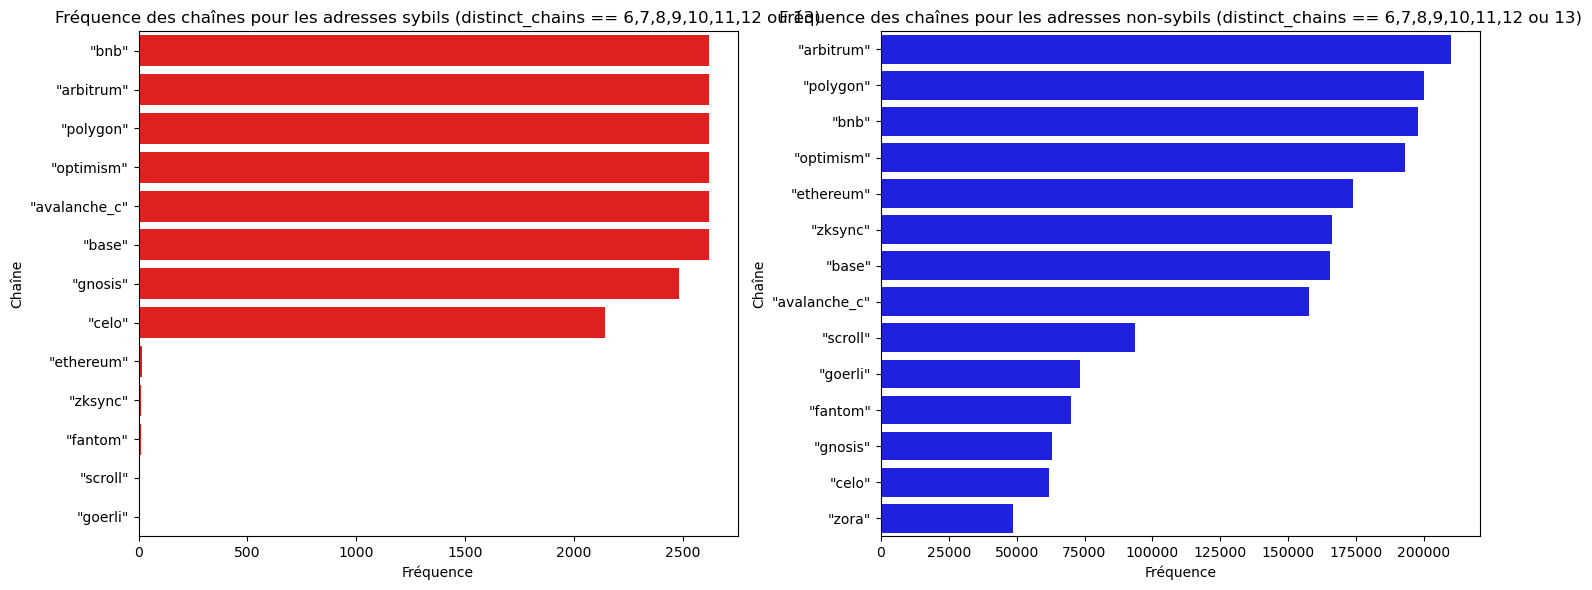

In [ ]:
# Initialiser des compteurs pour sybils et non-sybils
sybil_counter = Counter()
non_sybil_counter = Counter()

# Filtrer les lignes où distinct_chains est égal à 7 ou 8
filtered_df = df1[df1['distinct_chains'].isin([6,7,8,9,10,11,12,13])]

# Parcourir chaque liste dans la colonne 'chains_list' et la variable catégorielle 'sybil'
for chains, is_sybil in zip(filtered_df['chains_list'], filtered_df['sybil']):
    if is_sybil:
        sybil_counter.update(chains)
    else:
        non_sybil_counter.update(chains)

# Convertir les Counters en DataFrames
sybil_freq_df = pd.DataFrame.from_dict(sybil_counter, orient='index', columns=['Frequency']).reset_index()
sybil_freq_df.columns = ['Chain', 'Frequency']
sybil_freq_df['Percentage'] = (sybil_freq_df['Frequency'] / sybil_freq_df['Frequency'].sum()) * 100
sybil_freq_df = sybil_freq_df.sort_values(by='Frequency', ascending=False)

non_sybil_freq_df = pd.DataFrame.from_dict(non_sybil_counter, orient='index', columns=['Frequency']).reset_index()
non_sybil_freq_df.columns = ['Chain', 'Frequency']
non_sybil_freq_df['Percentage'] = (non_sybil_freq_df['Frequency'] / non_sybil_freq_df['Frequency'].sum()) * 100
non_sybil_freq_df = non_sybil_freq_df.sort_values(by='Frequency', ascending=False)

# Créer une figure avec deux sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualisation pour les adresses sybils avec couleur rouge
sns.barplot(x='Frequency', y='Chain', data=sybil_freq_df, color='red', ax=axes[0])
axes[0].set_title('Fréquence des chaînes pour les adresses sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13)')
axes[0].set_xlabel('Fréquence')
axes[0].set_ylabel('Chaîne')

# Visualisation pour les adresses non-sybils avec couleur bleue
sns.barplot(x='Frequency', y='Chain', data=non_sybil_freq_df, color='blue', ax=axes[1])
axes[1].set_title('Fréquence des chaînes pour les adresses non-sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13)')
axes[1].set_xlabel('Fréquence')
axes[1].set_ylabel('Chaîne')

# Ajuster la mise en page pour éviter les chevauchements
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [ ]:
# Afficher les résultats
print("Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13) :")
print(sybil_freq_df)
print("\nFréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13) :")
print(non_sybil_freq_df)

Fréquence et pourcentage des chaînes pour les adresses sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13) :
            Chain  Frequency  Percentage
5           "bnb"       2620   12.847546
7      "arbitrum"       2620   12.847546
2       "polygon"       2619   12.842642
3      "optimism"       2619   12.842642
6   "avalanche_c"       2619   12.842642
1          "base"       2618   12.837738
0        "gnosis"       2481   12.165939
4          "celo"       2144   10.513411
8      "ethereum"         14    0.068651
9        "zksync"         13    0.063747
11       "fantom"         12    0.058844
12       "scroll"          9    0.044133
10       "goerli"          5    0.024518

Fréquence et pourcentage des chaînes pour les adresses non-sybils (distinct_chains == 6,7,8,9,10,11,12 ou 13) :
            Chain  Frequency  Percentage
2      "arbitrum"     210233   11.212110
6       "polygon"     200083   10.670792
1           "bnb"     198059   10.562848
7      "optimism"     193096   10.298162


L'essentiel est que dans ce cas d'étude, les adresses sybils interagissent très peu avec ethereum, zksync, fantom, scrool et goerli et pas du tout avec zora.

### Conclusion sur ces études

Les résultats de ces études seront utilisés à l'étape 5 pour construire de nouvelles variables opérationnelles en vue de l'élaboration du modèle.

In [ ]:
df_non_sybil

,address,distinct_chains,chains_list,gas_spent_eth,tx_count,unique_contracts,sybil,first_interact_unix,last_interact_unix,duration
0,0x9161d214972a52958f5a38695a524db4ec8b77de,1,[arbitrum],0.202633,275,29,0,1.701438e+09,1.713782e+09,12344346.0
1,0xca01a7d566d244369aa2c68fe9599d1778888888,2,[goerli arbitrum],0.198780,275,28,0,1.686901e+09,1.712741e+09,25840201.0
2,0xfcaa07a4a18cc908d34940935d636d7de0763afe,3,[bnb ethereum arbitrum],0.053277,275,28,0,1.701506e+09,1.713154e+09,11647643.0
3,0xfe2dd9c25c89a57c544ca7f82581ed4403d597fb,5,[base optimism arbitrum ethereum bnb],0.016917,275,27,0,1.708247e+09,1.715429e+09,7181906.0
4,0xfba0d5a2177b17d72e4f8e6ea35b98db507b510a,8,[base bnb arbitrum goerli ethereum zksync poly...,0.033302,275,26,0,1.687695e+09,1.713616e+09,25921233.0
...,...,...,...,...,...,...,...,...,...,...
370433,0x56f232cfc26e2f3dd55aa30c26eca7bad6c656db,6,[optimism ethereum polygon arbitrum zksync bnb],0.002423,25,5,0,1.705430e+09,1.715031e+09,9601636.0
370434,0x873b6d85d791d771040acdb3ecaa1f848314e921,1,[arbitrum],0.004661,25,5,0,1.705074e+09,1.709038e+09,3964307.0
370435,0xe95073db6276c6d45930d940e02828ccac8d6de6,1,[arbitrum],0.000965,25,5,0,1.705992e+09,1.706892e+09,900444.0
370436,0xec043d656d28cbbf36644aa746c82d538360e084,6,[bnb avalanche_c polygon optimism arbitrum base],0.002636,25,5,0,1.689117e+09,1.704311e+09,15193694.0


Passons à l'analyse superposée des densités, qui nous permettra de mettre en évidence les différences de comportements ainsi que les similitudes.

### Analyse de densité superposée sybil et non sybil

# Visualisation 10

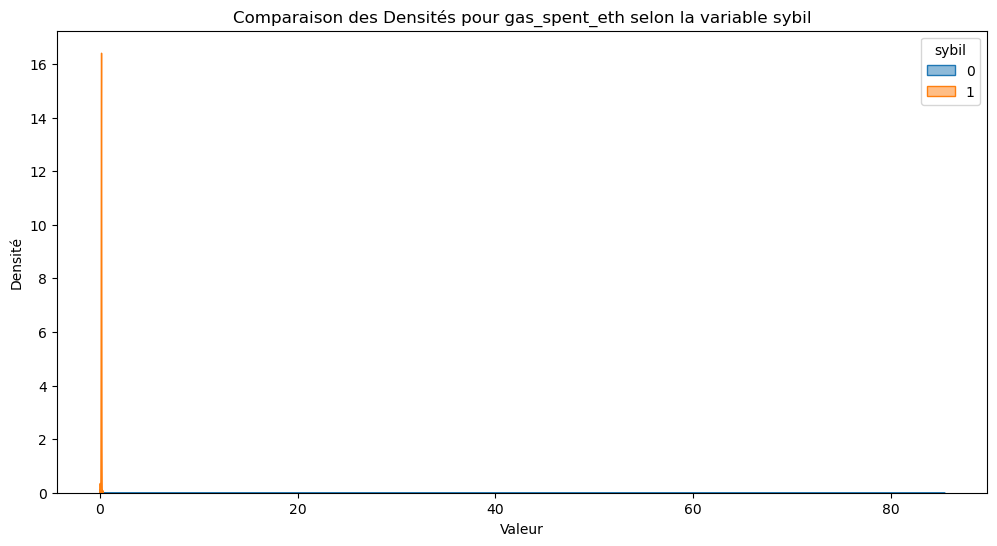

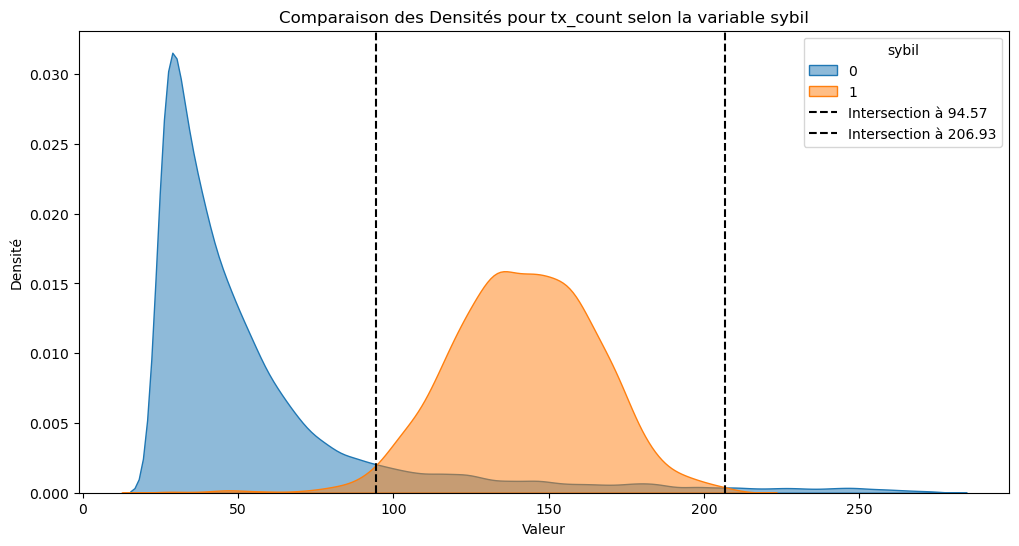

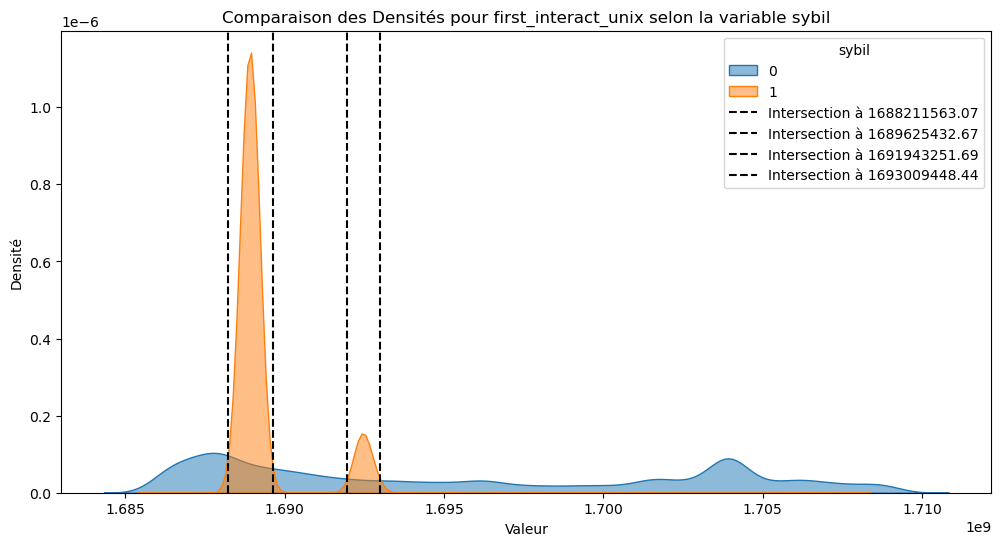

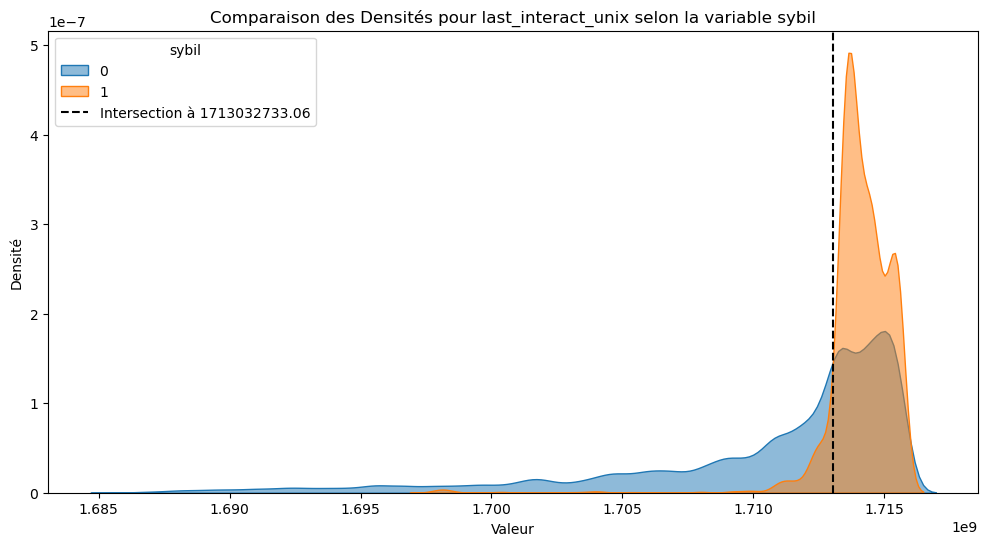

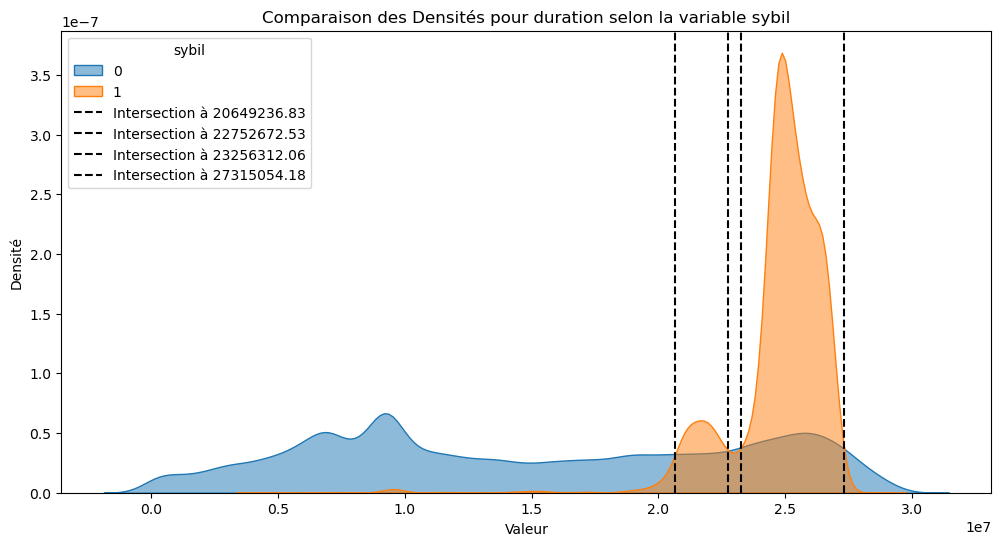

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Variables quantitatives à comparer
Features = ['gas_spent_eth', 'tx_count', 'first_interact_unix', 'last_interact_unix', 'duration']

# Tracer les courbes de densité et trouver les intersections
for var in Features:
    plt.figure(figsize=(12, 6))

    # Tracer les courbes de densité pour chaque catégorie de 'sybil'
    for label in df1['sybil'].unique():
        subset = df1[df1['sybil'] == label]
        sns.kdeplot(subset[var], label=f'{label}', fill=True, alpha=0.5)

    # Si la variable est différente de 'gas_spent_eth', trouver et tracer les intersections
    if var != 'gas_spent_eth':
        # Estimer les densités
        densities = {}
        x = np.linspace(df1[var].min(), df1[var].max(), 1000)

        # Calculer les densités pour chaque catégorie
        for label in df1['sybil'].unique():
            subset = df1[df1['sybil'] == label]
            density = stats.gaussian_kde(subset[var])
            densities[label] = density

        # Trouver les points d'intersection
        diff = densities[1](x) - densities[0](x)
        intersection_indices = np.where(np.diff(np.sign(diff)))[0]

        # Tracer les lignes verticales pour chaque point d'intersection
        for idx in intersection_indices:
            separation_value = x[idx]
            plt.axvline(x=separation_value, color='black', linestyle='--', label=f'Intersection à {separation_value:.2f}')

    plt.title(f'Comparaison des Densités pour {var} selon la variable sybil')
    plt.xlabel('Valeur')
    plt.ylabel('Densité')
    plt.legend(title='sybil')

    # Enregistrer le graphique en fichier PDF
    plt.savefig(f'density_plot_{var}.pdf', format='pdf')

    plt.show()


- **La visualisation des densités superposées pour la variable `gas_spent_eth` est illisible en raison des valeurs aberrantes présentes pour les adresses non-sybils (ce problème sera traité ultérieurement). À l'exception de cela, la majorité des valeurs prises sont proches de 0.**
- **La visualisation des densités superposées pour la variable `tx_count` est très lisible et montre que les densités se séparent autour de la valeur 95 : les adresses sybils sont majoritairement distribuées dans l'intervalle [100;200], tandis que les adresses non-sybils sont concentrées dans l'intervalle [31;62] (Q1, Q3).**
- **Pour la variable `first_interact_unix`, les adresses sybils prennent majoritairement deux ensembles de valeurs, comme évoqué dans les visualisations précédentes, tandis que les adresses non-sybils ont une distribution plus uniforme.**
- **Pour la variable `last_interact_unix`, les densités semblent se confondre : la plupart des adresses prennent leurs valeurs dans l'intervalle [1.709000e+09, 1.714462e+09].**
- **Pour la variable `duration`, les adresses non-sybils montrent une distribution uniforme, tandis que les adresses sybils ont une distribution concentrée dans l'intervalle [2.450977e+07, 2.582549e+07] (Q1, Q3).**

In [ ]:
df_non_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,367818.000000,367818.000000,3.678180e+05,3.678180e+05,3.678180e+05
mean,0.008072,56.304678,1.695598e+09,1.710589e+09,1.499127e+07
std,0.165554,41.746199,7.288820e+06,5.772642e+06,8.114226e+06
min,0.000024,25.000000,1.686010e+09,1.686015e+09,1.600000e+01
25%,0.002315,31.000000,1.688557e+09,1.708952e+09,8.179688e+06
50%,0.003671,42.000000,1.693969e+09,1.712936e+09,1.427450e+07
75%,0.006463,62.000000,1.703433e+09,1.714457e+09,2.270875e+07
max,85.383263,275.000000,1.709165e+09,1.715643e+09,2.959624e+07


In [ ]:
df_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,2620.000000,2620.000000,2.620000e+03,2.620000e+03,2.620000e+03
mean,0.133882,141.962595,1.689352e+09,1.714067e+09,2.471490e+07
std,0.026002,23.343201,1.325346e+06,1.470549e+06,1.985502e+06
min,0.002014,27.000000,1.686185e+09,1.697786e+09,4.588585e+06
25%,0.118249,126.000000,1.688820e+09,1.713579e+09,2.450977e+07
50%,0.134776,142.000000,1.688956e+09,1.714057e+09,2.497143e+07
75%,0.150146,158.000000,1.689045e+09,1.714756e+09,2.582549e+07
max,0.269295,209.000000,1.707566e+09,1.715583e+09,2.855194e+07


## Importance de la Variable de Gaz

La question de l'importance de la variable `gas_spent_eth` est pertinente. En effet, les densités superposées pour cette variable ne fournissent pas des insights concluants. L'analyse des courbes de densité superposées révèle que les distributions pour les adresses sybils et non-sybils se chevauchent considérablement, ce qui suggère un manque de différences significatives entre les deux groupes pour cette variable. Cela indique que la variable `gas_spent_eth` pourrait ne pas être un facteur discriminant efficace dans ce contexte. Donc ajustons l'échelle des valeurs prises.


In [ ]:
# Describe de la variable gaz_spend selon les adresses sybils ou non

# Describe de la variable 'gaz_spend' pour les adresses sybils
describe_sybil = df_sybil['gas_spent_eth'].describe()

# Describe de la variable 'gaz_spend' pour les adresses non-sybils
describe_non_sybil = df_non_sybil['gas_spent_eth'].describe()

# Combiner les deux séries dans un DataFrame
describe_combined = pd.DataFrame({
    'Sybil': describe_sybil,
    'Non-Sybil': describe_non_sybil
})

# Afficher le DataFrame combiné
print(describe_combined)

             Sybil      Non-Sybil
count  2620.000000  367818.000000
mean      0.133882       0.008072
std       0.026002       0.165554
min       0.002014       0.000024
25%       0.118249       0.002315
50%       0.134776       0.003671
75%       0.150146       0.006463
max       0.269295      85.383263


En examinant la valeur maximale observée dans le groupe des adresses non-sybils, nous devons nous interroger sur la présence éventuelle de valeurs aberrantes. Cette valeur extrême pourrait-elle indiquer des anomalies dans les données ? Pour répondre à cette question, il est essentiel de comparer cette valeur avec les autres observations et d'évaluer si elle se situe en dehors des plages de valeurs attendues. Cette analyse nous aidera à déterminer si cette valeur doit être considérée comme une aberration ou si elle représente un phénomène valide mais rare.


# Visualisation 11

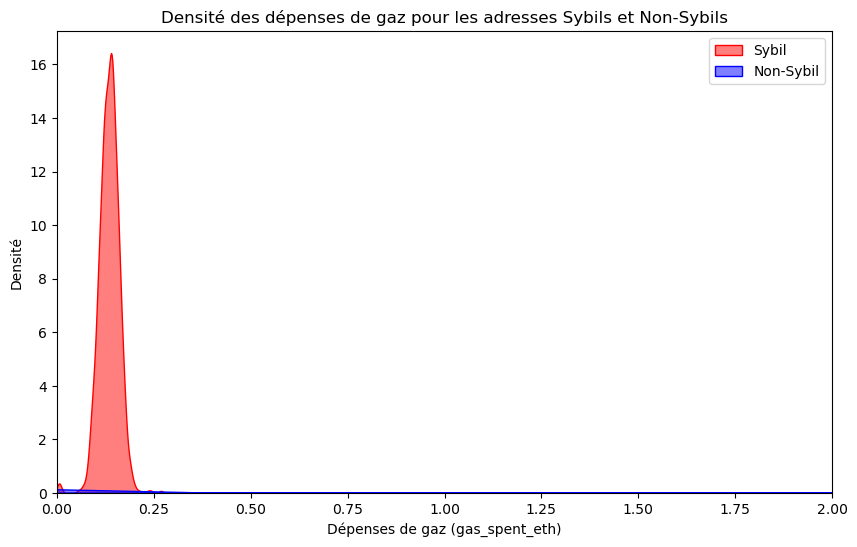

In [ ]:
# Créer la figure et l'axe pour la visualisation
plt.figure(figsize=(10, 6))

# Tracer les courbes de densité pour 'gas_spent_eth' dans les deux DataFrames
sns.kdeplot(df_sybil['gas_spent_eth'], label='Sybil', fill=True, color='red', alpha=0.5)
sns.kdeplot(df_non_sybil['gas_spent_eth'], label='Non-Sybil', fill=True, color='blue', alpha=0.5)

# Ajuster les limites de l'axe x
plt.xlim(0, 2)

# Ajouter les titres et labels
plt.title('Densité des dépenses de gaz pour les adresses Sybils et Non-Sybils')
plt.xlabel('Dépenses de gaz (gas_spent_eth)')
plt.ylabel('Densité')

# Ajouter une légende
plt.legend()

# Enregistrer le graphique en fichier PDF
plt.savefig('density_plot.pdf', format='pdf')

# Afficher le graphique
plt.show()


In [ ]:
df_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,2620.000000,2620.000000,2.620000e+03,2.620000e+03,2.620000e+03
mean,0.133882,141.962595,1.689352e+09,1.714067e+09,2.471490e+07
std,0.026002,23.343201,1.325346e+06,1.470549e+06,1.985502e+06
min,0.002014,27.000000,1.686185e+09,1.697786e+09,4.588585e+06
25%,0.118249,126.000000,1.688820e+09,1.713579e+09,2.450977e+07
50%,0.134776,142.000000,1.688956e+09,1.714057e+09,2.497143e+07
75%,0.150146,158.000000,1.689045e+09,1.714756e+09,2.582549e+07
max,0.269295,209.000000,1.707566e+09,1.715583e+09,2.855194e+07


In [ ]:
df_non_sybil.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,367818.000000,367818.000000,3.678180e+05,3.678180e+05,3.678180e+05
mean,0.008072,56.304678,1.695598e+09,1.710589e+09,1.499127e+07
std,0.165554,41.746199,7.288820e+06,5.772642e+06,8.114226e+06
min,0.000024,25.000000,1.686010e+09,1.686015e+09,1.600000e+01
25%,0.002315,31.000000,1.688557e+09,1.708952e+09,8.179688e+06
50%,0.003671,42.000000,1.693969e+09,1.712936e+09,1.427450e+07
75%,0.006463,62.000000,1.703433e+09,1.714457e+09,2.270875e+07
max,85.383263,275.000000,1.709165e+09,1.715643e+09,2.959624e+07


- **Pour les adresses sybils, la distribution parait normale tandis que les addresses non-sybil, la distribution parait uniforme.**

Sur la totalité des adresses sybils, lesquelles doivent-on supprimer pour valider l'hypothèse suivante : les adresses sybils dépensent des sommes plus importantes en frais de transactions ? Comparons les statististiques descriptives de la variable `gas_spent_eth`entre df_sybil et df_non_sybil ( ou bien on différencie avec `sybil`avec df1

# Visualisation 12

          count      mean       std       min       25%       50%       75%  \
sybil                                                                         
0      367818.0  0.008072  0.165554  0.000024  0.002315  0.003671  0.006463   
1        2620.0  0.133882  0.026002  0.002014  0.118249  0.134776  0.150146   

             max  
sybil             
0      85.383263  
1       0.269295  


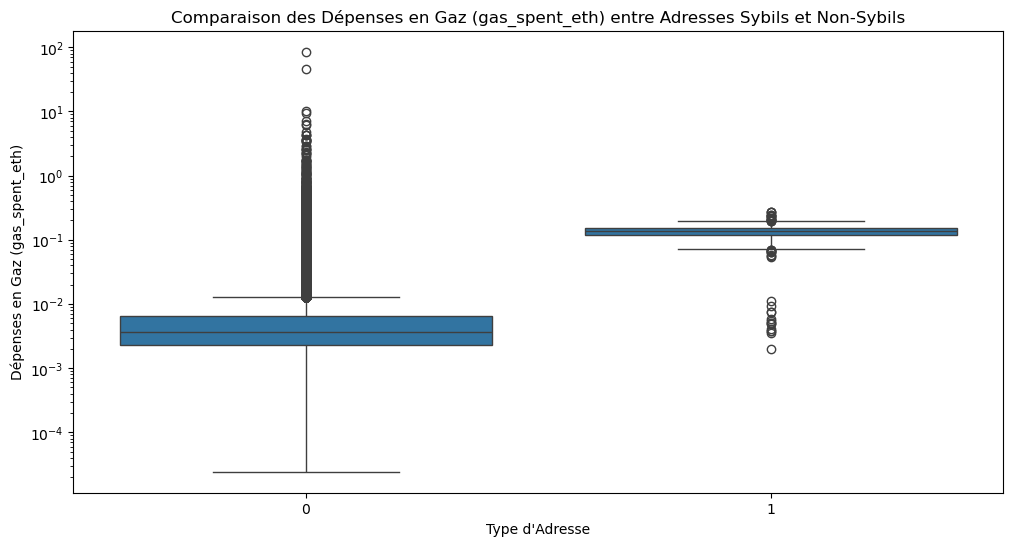

In [ ]:
# Calculer les statistiques descriptives pour gas_spent_eth par catégorie
# Explicitement passer observed=False pour éviter le warning
stats = df1.groupby('sybil', observed=False)['gas_spent_eth'].describe()
print(stats)

# Préparer les données pour la visualisation
plt.figure(figsize=(12, 6))

# Créer un boxplot pour comparer les distributions de gas_spent_eth
sns.boxplot(x='sybil', y='gas_spent_eth', data=df1)
plt.title('Comparaison des Dépenses en Gaz (gas_spent_eth) entre Adresses Sybils et Non-Sybils')
plt.xlabel('Type d\'Adresse')
plt.ylabel('Dépenses en Gaz (gas_spent_eth)')
plt.yscale('log')  # Utiliser une échelle logarithmique pour mieux visualiser les différences

# Sauvegarder la visualisation en PDF
plt.savefig('boxplot_gas_spent_eth.pdf', format='pdf')

# Afficher la visualisation
plt.show()


1. **df1** : Jeu de données initial contenant toutes les adresses.
2. **df_sybil** : Sous-ensemble de df1 avec uniquement les adresses sybils.
3. **df_non_sybil** : Sous-ensemble de df1 avec uniquement les adresses non-sybils.
4. **df1_copy_adjusted** : Une copie de df1 où les valeurs aberrantes sont supprimées selon les règles spécifiques à chaque catégorie (sybil ou non-sybil).
6. **df_non_sybil_bis** : Jeu de données où, pour les adresses non-sybils, toutes les valeurs supérieures à la borne supérieure sont supprimées.

L'objectif est de nettoyer les valeurs aberrantes des deux groupes (sybil et non-sybil) de manière à comparer les résultats après ajustement.

### Confection du jeu de données df_non_sybil_bis
On va supprimer toutes les valeurs aberrantes supérieur à la borne supérieur construite à aprtir un d'un boxplot qui est défini dans le code suivant :

In [ ]:
# Calculer les quartiles
Q1 = df_non_sybil['gas_spent_eth'].quantile(0.25)
Q3 = df_non_sybil['gas_spent_eth'].quantile(0.75)

# Calculer l'IQR
IQR = Q3 - Q1

# Calculer la borne supérieure
borne_superieure = Q3 + 1.5 * IQR
borne_superieure

0.01268622251140375

Suppression des observations ayant pour `'gas_spent_eth'` une valeur supérieure à 0.01268622251140375. Faites cette suppression sur la copie de `df_non_sybil`, appelée `df_non_sybil_bis`.

In [ ]:
import pandas as pd

# Supposons que df_non_sybil_bis est déjà une copie de df_non_sybil
df_non_sybil_bis = df_non_sybil.copy()

# Condition pour filtrer les lignes
condition = df_non_sybil_bis['gas_spent_eth'] <= 0.01268622251140375

# Application de la condition pour obtenir les lignes qui respectent le critère
df_non_sybil_bis = df_non_sybil_bis.loc[condition]

In [ ]:
df_non_sybil_bis.describe()

,gas_spent_eth,tx_count,first_interact_unix,last_interact_unix,duration
count,327936.000000,327936.000000,3.279360e+05,3.279360e+05,3.279360e+05
mean,0.004013,47.598586,1.695168e+09,1.710592e+09,1.542442e+07
std,0.002593,26.397450,7.269870e+06,5.827483e+06,8.131109e+06
min,0.000024,25.000000,1.686010e+09,1.686015e+09,1.600000e+01
25%,0.002179,30.000000,1.688326e+09,1.708977e+09,8.583079e+06
50%,0.003319,39.000000,1.693103e+09,1.713003e+09,1.539121e+07
75%,0.005181,55.000000,1.702935e+09,1.714473e+09,2.318419e+07
max,0.012686,275.000000,1.709165e+09,1.715643e+09,2.959624e+07


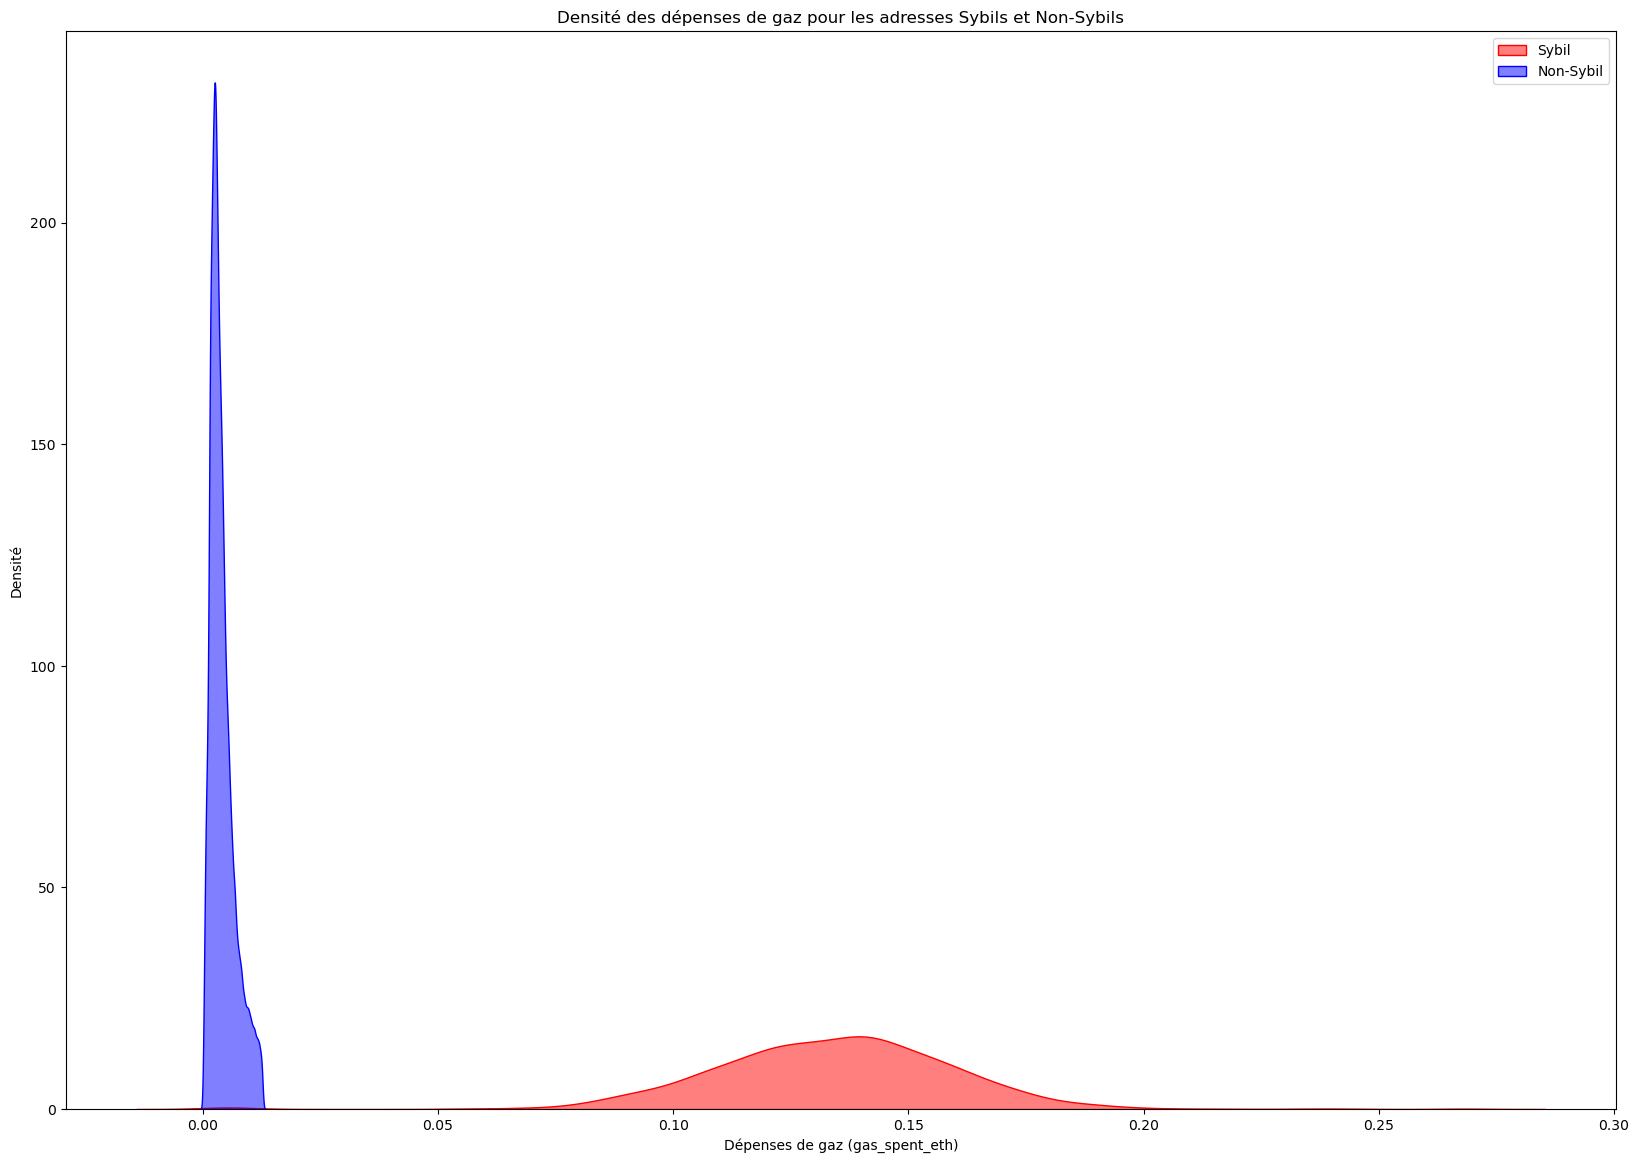

In [ ]:
# Créer la figure et l'axe pour la visualisation
plt.figure(figsize=(20, 14))

# Tracer les courbes de densité pour 'gas_spent_eth' dans les deux DataFrames
sns.kdeplot(df_sybil['gas_spent_eth'], label='Sybil', fill=True, color='red', alpha=0.5)
sns.kdeplot(df_non_sybil_bis['gas_spent_eth'], label='Non-Sybil', fill=True, color='blue', alpha=0.5)

# Ajouter les titres et labels
plt.title('Densité des dépenses de gaz pour les adresses Sybils et Non-Sybils')
plt.xlabel('Dépenses de gaz (gas_spent_eth)')
plt.ylabel('Densité')

# Ajouter une légende
plt.legend()

# Afficher le graphique
plt.show()

L'analyse des densités superposées fournit une visualisation plus informative des distributions. La suppression de certaines valeurs aberrantes a permis d'améliorer cette visualisation, offrant ainsi des résultats plus clairs et pertinents.

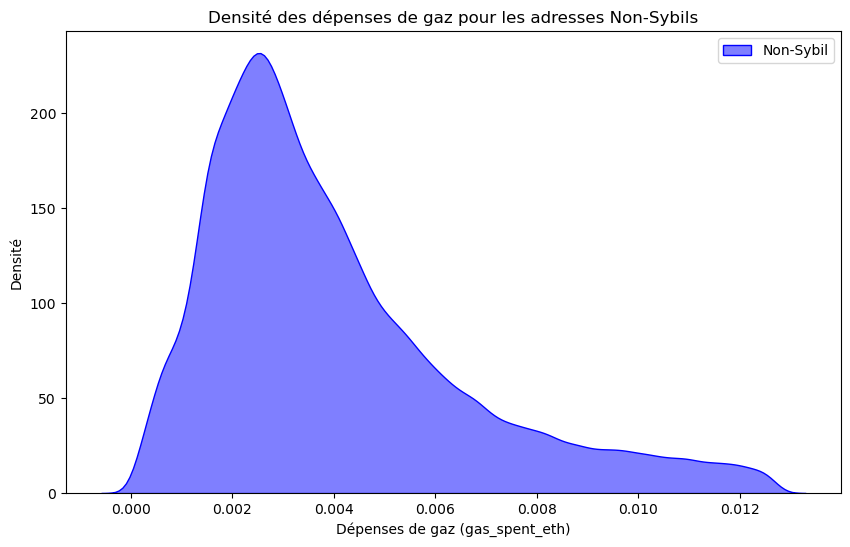

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer la figure et l'axe pour la visualisation
plt.figure(figsize=(10, 6))

# Tracer la courbe de densité pour 'gas_spent_eth' dans df_non_sybil_bis
sns.kdeplot(df_non_sybil_bis['gas_spent_eth'], label='Non-Sybil', fill=True, color='blue', alpha=0.5)

# Ajouter les titres et labels
plt.title('Densité des dépenses de gaz pour les adresses Non-Sybils')
plt.xlabel('Dépenses de gaz (gas_spent_eth)')
plt.ylabel('Densité')

# Ajouter une légende
plt.legend()

# Afficher le graphique
plt.show()

La suppression des valeurs aberrantes a permis une visualisation plus claire et approfondie de la courbe de densité. Cette approche s'est révélée efficace pour améliorer la qualité de l'analyse. Nous devons rester ouverts à d'éventuelles nouvelles stratégies ou ajustements à l'avenir pour affiner encore davantage nos analyses.

In [ ]:
import pandas as pd

# Supposons que df_sybil et df_non_sybil_bis sont déjà définis
# Étape 2 : Concaténer les DataFrames
df1_copy_adjusted = pd.concat([df_sybil, df_non_sybil_bis], ignore_index=True)

In [ ]:
# Appliquer la transformation à chaque élément de la colonne 'chains_list'
df1_copy_adjusted['chains_list'] = df1_copy_adjusted['chains_list'].apply(transform_chain)

## Étape 4 : Analyse bivariée
<a id="étape-4--analyse-bivariée"></a>
- **Comprendre les corrélations entre les variables quantitatives.**
- **Comprendre les relations entre les variables qualitatives.**

Dans cette étape, 2 visualisations sont faites :
- Matrice de corrélation ( pour df_sybil et df_non_sybil )
- Matrice de chaleur ( pour df_sybil et df_non_sybil )

Comprendre les corrélations entre variables quantitatives aide à identifier les relations linéaires pour améliorer les modèles prédictifs, tandis que l'analyse des relations entre variables qualitatives révèle des patterns et des associations importantes; pour ce faire, des visualisations comme la matrice de corrélation et la matrice de chaleur sont utilisées pour simplifier l'interprétation des données.

# Visualisation 13

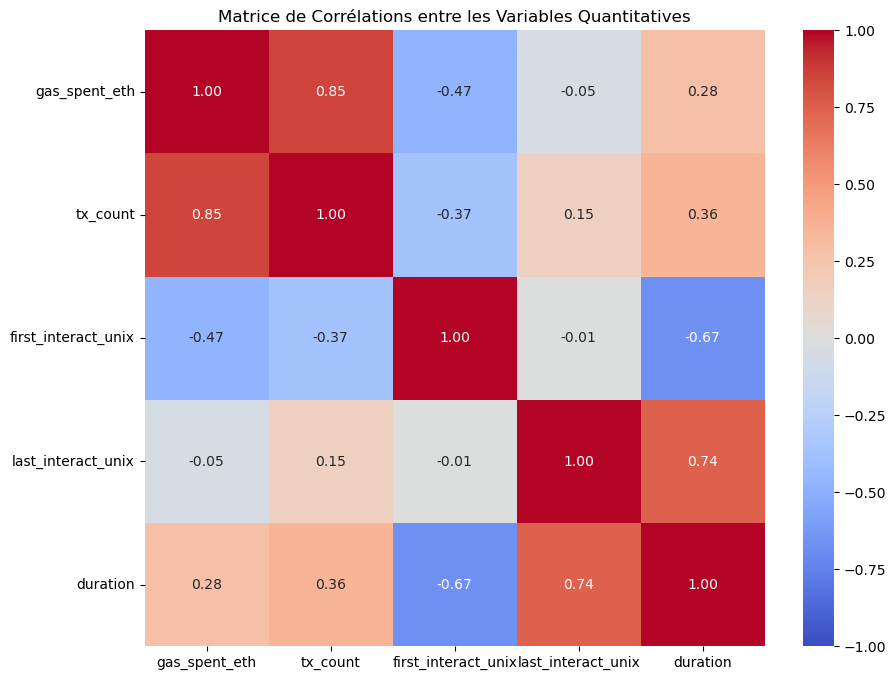

In [ ]:
# Relation entre les variables quantitatives

# Sélectionner les colonnes numériques de df1
df1_numeriques = df_sybil.select_dtypes(include=[np.number])

# Calculer la matrice de corrélations
corr_matrix = df1_numeriques.corr()

# Créer la heatmap de la matrice de corrélations
plt.figure(figsize=(10, 8))  # Ajuster la taille de la figure si nécessaire
heatmap = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

# Ajouter un titre à la heatmap
plt.title('Matrice de Corrélations entre les Variables Quantitatives')

# Afficher la heatmap
plt.show()

La matrice de corrélation révèle que `gas_spent_eth` et `tx_count` sont fortement corrélés (0.85), tandis que `duration` est positivement corrélée avec `last_interact_unix` (0.74) et négativement avec `first_interact_unix` (-0.67), tandis que les autres variables montrent des relations plus faibles ou modérées.

# Visualisation 14

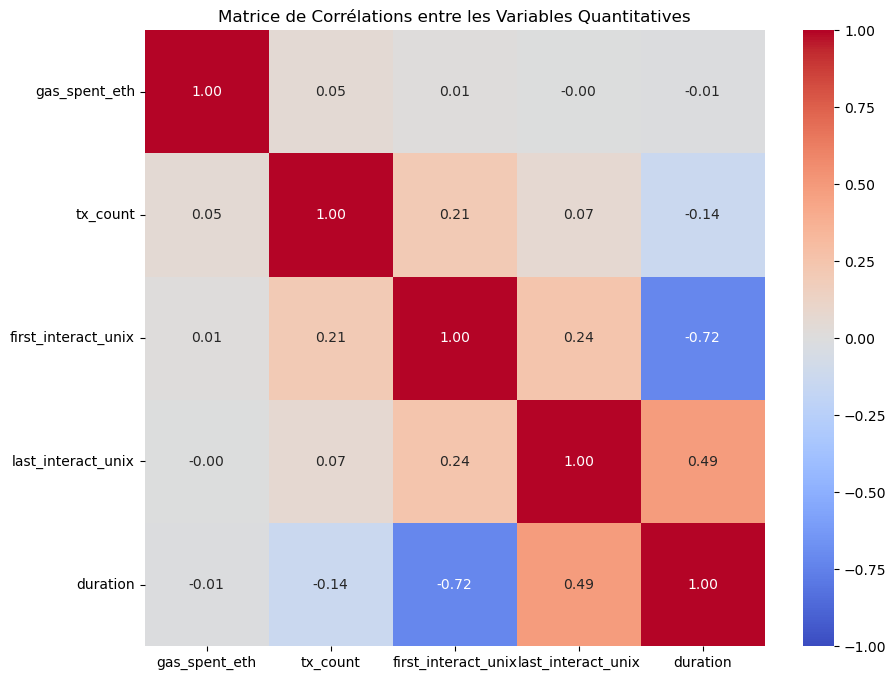

In [ ]:
# Relation entre les variables quantitatives

# Sélectionner les colonnes numériques de df1
df1_numeriques = df_non_sybil.select_dtypes(include=[np.number])

# Calculer la matrice de corrélations
corr_matrix = df1_numeriques.corr()

# Créer la heatmap de la matrice de corrélations
plt.figure(figsize=(10, 8))  # Ajuster la taille de la figure si nécessaire
heatmap = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

# Ajouter un titre à la heatmap
plt.title('Matrice de Corrélations entre les Variables Quantitatives')

# Afficher la heatmap
plt.show()

La matrice de corrélation montre que les variables `gas_spent_eth` et `tx_count` ont une corrélation très faible (0.05), `first_interact_unix` est fortement négativement corrélée avec `duration` (-0.72), et `last_interact_unix` est modérément positivement corrélée avec `duration` (0.49).

# Visualisation 15

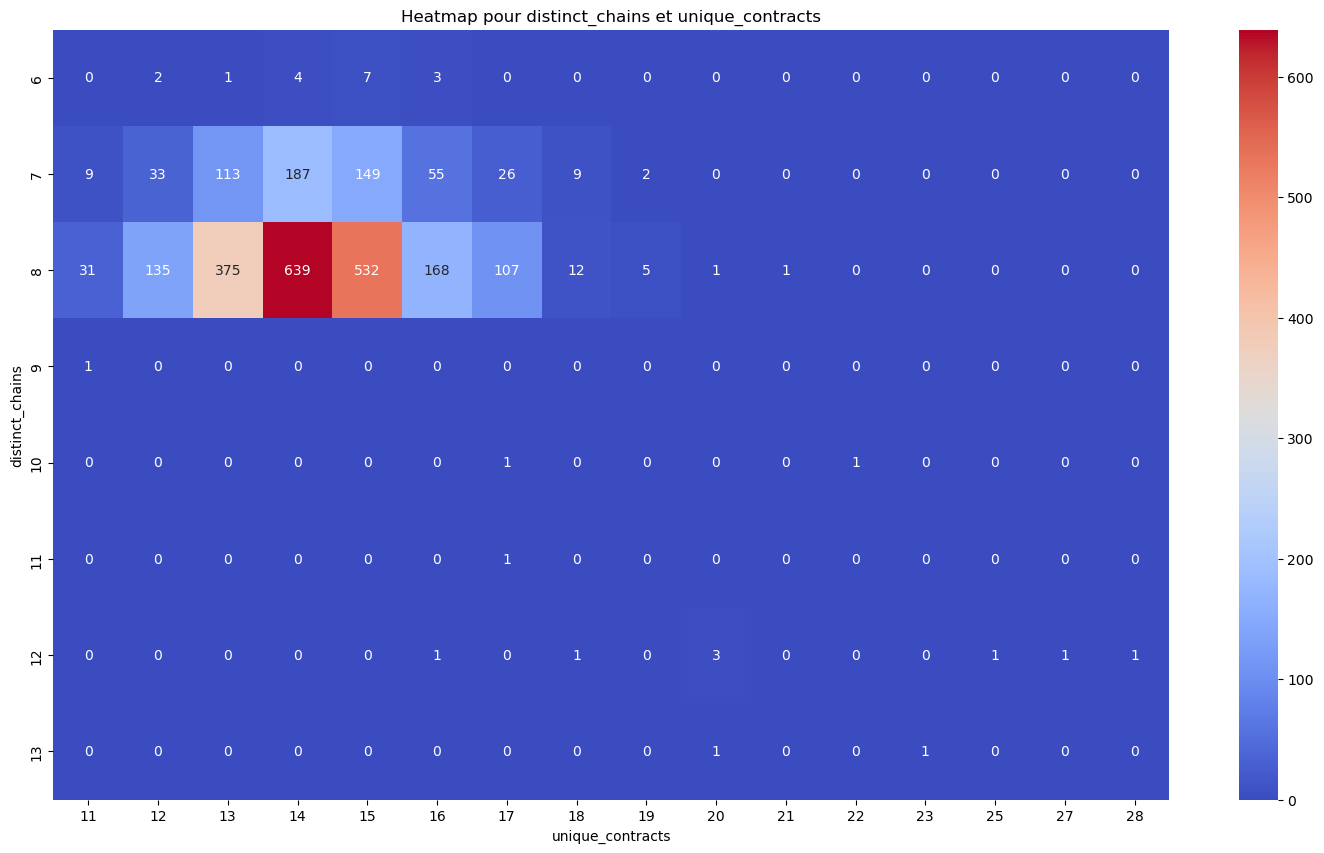

In [ ]:
# Créer une table de contingence pour la heatmap
contingency_table = pd.crosstab(df_sybil['distinct_chains'], df_sybil['unique_contracts'])

# Tracer la matrice de chaleur
plt.figure(figsize=(18, 10))
sns.heatmap(contingency_table, annot=True, cmap='coolwarm', fmt='d')
plt.title('Heatmap pour distinct_chains et unique_contracts')
plt.xlabel('unique_contracts')
plt.ylabel('distinct_chains')
plt.show()

Cette matrice de chaleur révèle que les adresses sybils interagissent principalement avec 7 à 8 chaînes distinctes et avec entre 12 et 17 contrats uniques sur Arbitrum.

# Visualisation 16

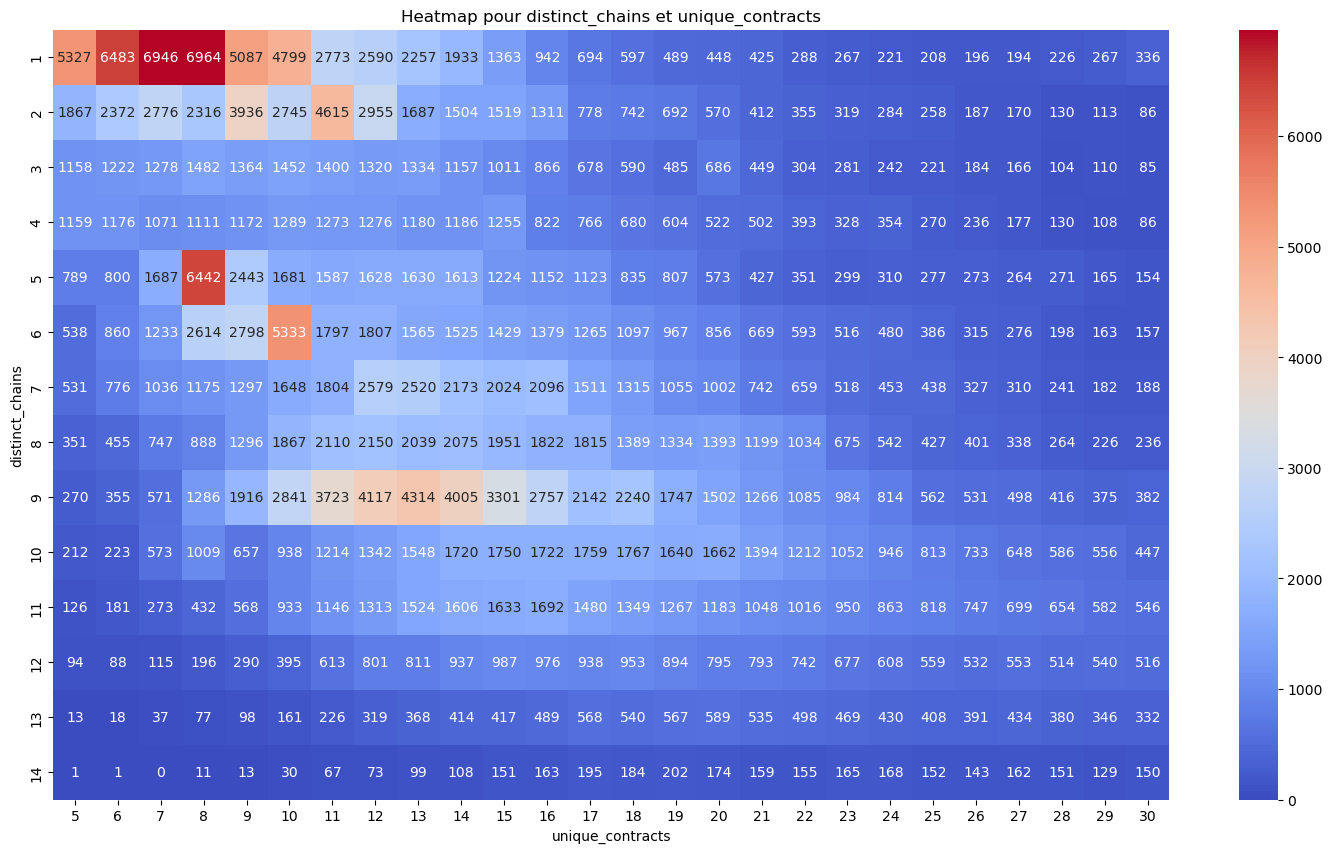

In [ ]:
# Créer une table de contingence pour la heatmap
contingency_table = pd.crosstab(df_non_sybil['distinct_chains'], df_non_sybil['unique_contracts'])

# Tracer la matrice de chaleur
plt.figure(figsize=(18, 10))
sns.heatmap(contingency_table, annot=True, cmap='coolwarm', fmt='d')
plt.title('Heatmap pour distinct_chains et unique_contracts')
plt.xlabel('unique_contracts')
plt.ylabel('distinct_chains')
plt.show()

Cette matrice de chaleur nous indique qu'il existe trois familles de modalités fréquentes, illustrées par un dégradé de bleu très clair à rouge. Cependant, on observe également une répartition relativement uniforme au-delà de ces zones particulières.

### Conclusion Générale des Étapes d'Analyse

À partir de ces analyses approfondies, nous avons identifié des éléments clés pour la création de **features** pertinentes, qui seront essentielles pour la construction de nos futurs modèles. Ces caractéristiques optimisées nous permettront d'obtenir des résultats précis et significatifs, renforçant ainsi la qualité de nos prédictions.

## Portrait robot

### Portrait Robot des Données

Pour les remarques 1 à 4, voir Visualisation 1 ; pour les autres, voir Visualisation 2.

Le caractère **sybil** d’une adresse présente les caractéristiques suivantes :
1. **Transactions** : 75 % des valeurs pour la variable `tx_count` sont supérieures à 126, indiquant une fréquence élevée d’interactions.
2. **Dépenses en gaz** : La valeur moyenne pour `gas_spent_eth` est de 0,133882 avec un écart-type faible de 0,026002, révélant des dépenses relativement homogènes et concentrées.
3. **Première Interaction** : 75 % des valeurs de `first_interact_unix` se situent dans l'intervalle [1.686185e+09, 1.689045e+09], suggérant une faible variabilité dans le temps de première interaction.
4. **Durée** : L'écart-type pour la variable `duration` est près de 4 fois plus petit que celui des adresses non-sybils, avec 75 % des valeurs comprises dans l’intervalle [2.450977e+07, 2.855194e+07], indiquant une durée d'interaction relativement uniforme.
5. **Chaînes Distinctes** : 98 % des adresses sybils interagissent avec 7 ou 8 chaînes distinctes, montrant une concentration élevée sur un nombre restreint de chaînes.
6. **Contrats Uniques** : Pour `unique_contracts`, 99 % des valeurs se situent parmi {11, 12, 13, 14, 15, 16, 17, 18}, révélant une interaction répétée avec un nombre limité de contrats.

Pour les remarques 1 à 4, voir Visualisation 3 ; pour les autres, voir Visualisation 4.

Le caractère **non-sybil** d’une adresse présente les caractéristiques suivantes :
1. **Transactions** : 75 % des valeurs pour `tx_count` sont inférieures à 62, ce qui indique une fréquence d’interactions plus faible.
2. **Dépenses en gaz** : La moyenne pour `gas_spent_eth` est de 0,008072, environ 20 fois plus faible que celle des adresses sybils, avec un écart-type élevé en raison de valeurs aberrantes.
3. **Première Interaction** : La variable `first_interact_unix` montre un écart-type élevé, suggérant une distribution plus uniforme des premières interactions, contrairement aux adresses sybils.
4. **Durée** : L'écart-type pour `duration` est environ 4 fois plus grand que celui des adresses sybils, avec 75 % des valeurs dans l’intervalle [1.600000e+01, 2.270875e+07], indiquant une plus grande variabilité dans la durée des interactions.
5. **Chaînes Distinctes** : 84,4 % des valeurs pour `distinct_chains` ne correspondent pas aux 7 ou 8 chaînes observées chez les sybils, montrant une plus grande diversité dans les chaînes d'interaction.
6. **Contrats Uniques** : Pour `unique_contracts`, les valeurs 8, 9, 10, 11, 12, 13, 14, et 15 comptent pour plus de 20 000 occurrences chacune, représentant 51,1 % du total des observations, indiquant une large dispersion parmi ces valeurs.

## Étape 5 : Feature Engineering pour les futurs modèles
<a id="étape-5--feature-engineering-pour-les-futurs-modèles"></a>

Il est important de noter que nous avons deux ensembles de données :

- `df1_copy_adjusted`
- `df1`

Le premier ensemble a subi des modifications : des observations considérées comme des valeurs aberrantes pour la variable `gas_spent_eth` ont été supprimées à des fins de visualisation. Nous allons maintenant vérifier si nos modèles percevront cette modification comme bénéfique.

La variable `chains_list` a subi le changement le plus significatif, car chacune de ses modalités a été transformée en variable binaire. Toutes les variables qualitatives ont été encodées en one-hot, tandis que les variables quantitatives n'ont pas été modifiées.

## Étape 6 : Construction du modèle
<a id="étape-6-construction-du-modèle"></a>

**Développement et évaluation des modèles prédictifs.**

- Nous allons mettre en place deux modèles de prédiction différents et évaluer leur performance. Chacun de ces modèles présente un intérêt particulier en raison de son fonctionnement, et nous nous efforcerons de maximiser les résultats pour chacun. Ensuite, nous ferons un bilan de leur construction. Les modèles que nous utiliserons sont XGBoost et SGDClassifier, car nous disposons d'un dataset de plus de 300 000 observations, un contexte dans lequel les techniques utilisant l'algorithme de descente de gradient sont fortement recommandées.
  
- Les modèles seront construits à partir de nos deux jeux de données dédiés à cette étape de prédiction (df1 et df1_copy_adjusted).

In [ ]:
# Ensemble des librairies exploitée lors cet étape
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Création d'un dataset approprié pour l'application d'un modèle de descente de gradient
df1_ml = df1.copy()
df1_ml_bis = df1_copy_adjusted.copy()

# Initialiser les encodeurs pour les colonnes catégorielles
label_encoders = {}

# Encoder la colonne 'distinct_chains' dans les deux DataFrames
le_chains = LabelEncoder()
df1_ml['distinct_chains'] = le_chains.fit_transform(df1_ml['distinct_chains'])
df1_ml_bis['distinct_chains'] = le_chains.transform(df1_ml_bis['distinct_chains'])
label_encoders['distinct_chains'] = le_chains

# Encoder la colonne 'unique_contracts' dans les deux DataFrames
le_contracts = LabelEncoder()
df1_ml['unique_contracts'] = le_contracts.fit_transform(df1_ml['unique_contracts'])
df1_ml_bis['unique_contracts'] = le_contracts.transform(df1_ml_bis['unique_contracts'])
label_encoders['unique_contracts'] = le_contracts

# Ajouter d'autres colonnes catégorielles si nécessaire
# Exemple pour une colonne supplémentaire 'category_column'
# le_category = LabelEncoder()
# df1_ml['category_column'] = le_category.fit_transform(df1_ml['category_column'])
# df1_ml_bis['category_column'] = le_category.transform(df1_ml_bis['category_column'])
# label_encoders['category_column'] = le_category

In [ ]:
# Convertir les listes en chaînes de caractères séparées par une virgule dans df1_ml
df1_ml['chains_list'] = df1_ml['chains_list'].apply(lambda x: ','.join(x) if isinstance(x, list) else x)
df1_ml_bis['chains_list'] = df1_ml_bis['chains_list'].apply(lambda x: ','.join(x) if isinstance(x, list) else x)

In [ ]:
# Liste des modalités sans doublons
modalites = [
    "arbitrum", "polygon", "optimism", "avalanche_c", "base",
    "gnosis", "celo", "ethereum", "zksync", "fantom",
    "scroll", "bnb", "goerli", "zora"
]
# Créer une colonne binaire pour chaque modalité et la convertir en catégorielle
for mod in modalites:
    df1_ml[mod] = df1_ml['chains_list'].apply(lambda x: 1 if mod in x else 0)
    df1_ml_bis[mod] = df1_ml_bis['chains_list'].apply(lambda x: 1 if mod in x else 0)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Préparer les données
X = df1_ml.drop(['address', 'sybil','chains_list'], axis=1)
y = df1_ml['sybil']   # Variable cible
X_bis = df1_ml_bis.drop(['address', 'sybil','chains_list'], axis=1)
y_bis = df1_ml_bis['sybil']   # Variable cible

## Modèle 1 : SGDclassifier

Le **SGDClassifier** repose sur la descente de gradient stochastique pour ajuster les paramètres du modèle. Il est particulièrement efficace pour les grandes quantités de données, car il effectue des mises à jour incrémentielles des poids à chaque itération. Ce modèle est adapté aux tâches de classification linéaire et supporte différentes fonctions de perte telles que la régression logistique ou la SVM linéaire. Grâce à sa simplicité et à sa capacité à traiter des ensembles de données volumineux, il est souvent utilisé dans des contextes nécessitant une mise à jour rapide des modèles.

## Entrainement et test sur df1_ml

In [ ]:
# Étape 2: Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Étape 3: Normalisation des données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Quelles paramêtres souhaitons-nous optomsier ? les principaux qui sont :
1. **`loss`** : Choix de la fonction de perte (par exemple, `'hinge'` pour SVM, `'log_loss'` pour régression logistique).

2. **`penalty`** : Type de régularisation (`'l2'`, `'l1'`, `'elasticnet'`), qui aide à prévenir le surapprentissage.

3. **`alpha`** : Coefficient de régularisation, contrôle l'intensité de la régularisation.

4. **`learning_rate`** : Stratégie pour ajuster le taux d'apprentissage (`'constant'`, `'optimal'`, etc.).

5. **`max_iter`** : Nombre maximum d'itérations d'entraînement.

6. **`tol`** : Tolérance pour la condition d'arrêt (quand l'optimisation doit s'arrêter).

7. **`shuffle`** : Mélange des données à chaque itération (`True` par défaut).

8. **`random_state`** : Fixe l'aléatoire pour la reproductibilité.

9. **`early_stopping`** : Arrête l'entraînement si l'erreur de validation n'améliore plus.

10. **`class_weight`** : Pondération des classes pour gérer les déséquilibres dans les données.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialisation du modèle SGDClassifier
sgd = SGDClassifier()

# Définition de la grille de paramètres
param_grid = {
    'loss': ['log_loss'],  # SVM linéaire et régression logistique
    'penalty': ['l2'],
    'alpha': [0.001, 0.01, 0.1],  # Valeurs possibles pour alpha
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.01, 0.1],  # Ajouter les valeurs possibles pour eta0
    'max_iter': [1000],  # Réduire le nombre d'itérations pour éviter les erreurs
    'tol': [1e-4, 1e-2],
    'shuffle': [True, False],
    'random_state': [42],  # Fixe pour la reproductibilité
    'early_stopping': [True, False],
    'class_weight': [None, 'balanced']
}

# Configuration de la recherche sur grille
grid_search = GridSearchCV(estimator=sgd, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Entraînement du modèle
grid_search.fit(X_train, y_train)

# Meilleurs paramètres trouvés par GridSearchCV
best_params = grid_search.best_params_
print("Meilleurs paramètres :", best_params)

# Meilleure performance obtenue
best_score = grid_search.best_score_
print("Meilleure performance (accuracy) :", best_score)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Meilleurs paramètres : {'alpha': 0.001, 'class_weight': 'balanced', 'early_stopping': True, 'eta0': 0.01, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 1000, 'penalty': 'l2', 'random_state': 42, 'shuffle': True, 'tol': 0.0001}
Meilleure performance (accuracy) : 0.9999654262431003


Précision (accuracy) sur l'ensemble de test : 0.9996369760101647
Rapport de classification :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     98375
           1       0.96      0.99      0.98       792

    accuracy                           1.00     99167
   macro avg       0.98      1.00      0.99     99167
weighted avg       1.00      1.00      1.00     99167



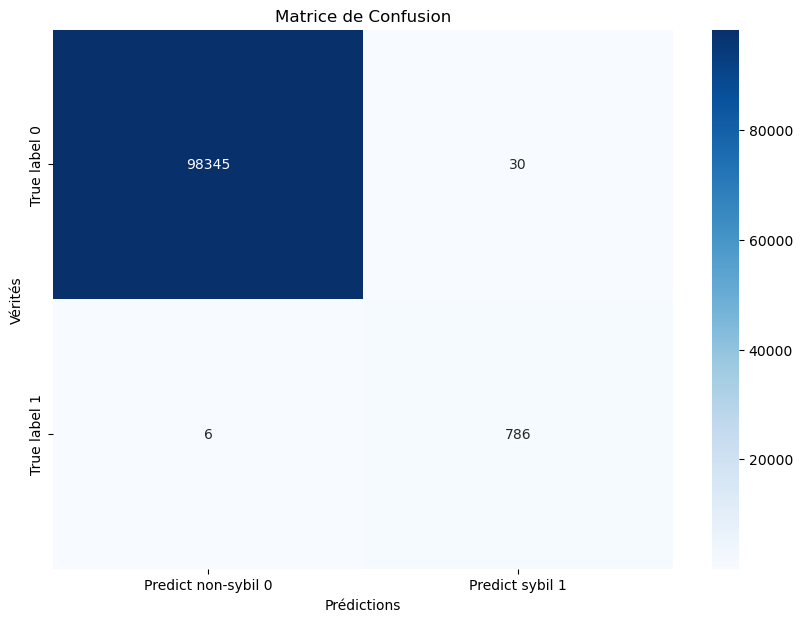

In [ ]:
# Prédictions sur l'ensemble de test
y_pred = grid_search.predict(X_test)

# Calcul des métriques d'évaluation
accuracy = accuracy_score(y_test, y_pred)
print("Précision (accuracy) sur l'ensemble de test :", accuracy)

# Rapport de classification
class_report = classification_report(y_test, y_pred)
print("Rapport de classification :\n", class_report)

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualisation de la matrice de confusion
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predict non-sybil 0', 'Predict sybil 1'], yticklabels=['True label 0', 'True label 1'])
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.title('Matrice de Confusion')
plt.show()


Un modèle avec ces 3 paramêtres fait l'affaire.

In [ ]:
sgd_clf.fit(X_train, y_train)

# Étape 5: Prédiction et évaluation
y_pred = sgd_clf.predict(X_test)

# Calculer la précision
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Rapport de classification
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matrice de confusion
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9992

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110309
           1       0.97      0.92      0.94       823

    accuracy                           1.00    111132
   macro avg       0.99      0.96      0.97    111132
weighted avg       1.00      1.00      1.00    111132


Confusion Matrix:
[[110288     21]
 [    69    754]]


Entrainement et test sur df1_ml_bis

In [ ]:
# Étape 2: Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_bis, y_bis, test_size=0.3, random_state=42)

# Étape 3: Normalisation des données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Étape 4: Entraînement du modèle SGDClassifier
sgd_clf = SGDClassifier(loss='log_loss',max_iter=150000, random_state=42)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Créer un pipeline avec standardisation et modèle SGDClassifier
pipeline = make_pipeline(StandardScaler(), sgd_clf)

# Entraîner le modèle
sgd_clf = pipeline.fit(X_train, y_train)

# Étape 5: Prédiction et évaluation
y_pred = sgd_clf.predict(X_test)

# Calculer la précision
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Rapport de classification
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matrice de confusion
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     98375
           1       1.00      0.98      0.99       792

    accuracy                           1.00     99167
   macro avg       1.00      0.99      0.99     99167
weighted avg       1.00      1.00      1.00     99167


Confusion Matrix:
[[98375     0]
 [   19   773]]


Les résultats obtenus sont excellents : la proportion de faux positifs est négligeable et aucun faux négatif n'a été détecté.

## Modèle 2 : XGBoost

Entrainement et test sur df_ml

In [ ]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_bis, y_bis, test_size=0.4, random_state=42)

### Quelles sont les meilleurs paramêtres pour un tel modèle dans notre situation ?

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Définir la grille des hyperparamètres
param_grid = {
    'n_estimators': [300],  # Réduit le nombre d'arbres à tester
    'max_depth': [16],  # Réduit les profondeurs d'arbres à tester
    'learning_rate': [0.2],  # Utilise une valeur de taux d'apprentissage
    'subsample': [0.8],  # Utilise une valeur de sous-échantillonnage
    'colsample_bytree': [0.5],  # Utilise une valeur de sous-échantillonnage des colonnes
    'lambda': [0.5],  # Utilise une valeur de régularisation L2
    'alpha': [1],  # Utilise une valeur de régularisation L1
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss']  # Utilise une seule métrique
}

# Initialiser GridSearchCV avec XGBClassifier
grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=5, scoring='accuracy')

# Entraîner le modèle avec GridSearchCV
grid_search.fit(X_train, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleurs hyperparamètres : ", grid_search.best_params_)

Meilleurs hyperparamètres :  {'alpha': 1, 'colsample_bytree': 0.5, 'eval_metric': 'logloss', 'lambda': 0.5, 'learning_rate': 0.2, 'max_depth': 16, 'n_estimators': 300, 'objective': 'binary:logistic', 'subsample': 0.8}


In [ ]:
# Initialiser et entraîner le modèle XGBoost
model = XGBClassifier(**grid_search.best_params_)  # Le paramètre use_label_encoder est supprimé
model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluer le modèle
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Afficher les résultats
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.9999
Confusion Matrix:
[[131160      2]
 [     7   1054]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    131162
           1       1.00      0.99      1.00      1061

    accuracy                           1.00    132223
   macro avg       1.00      1.00      1.00    132223
weighted avg       1.00      1.00      1.00    132223



Entrainement et test sur df_ml_bis

In [ ]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_bis, y_bis, test_size=0.4, random_state=42)

### Quelles sont les meilleurs paramêtres pour un tel modèle dans notre situation ?

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Définir la grille des hyperparamètres
param_grid = {
    'n_estimators': [300],  # Réduit le nombre d'arbres à tester
    'max_depth': [16],  # Réduit les profondeurs d'arbres à tester
    'learning_rate': [0.2],  # Utilise une valeur de taux d'apprentissage
    'subsample': [0.8],  # Utilise une valeur de sous-échantillonnage
    'colsample_bytree': [0.5],  # Utilise une valeur de sous-échantillonnage des colonnes
    'lambda': [0.5],  # Utilise une valeur de régularisation L2
    'alpha': [1],  # Utilise une valeur de régularisation L1
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss']  # Utilise une seule métrique
}

# Initialiser GridSearchCV avec XGBClassifier
grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=5, scoring='accuracy')

# Entraîner le modèle avec GridSearchCV
grid_search.fit(X_train, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleurs hyperparamètres : ", grid_search.best_params_)

Meilleurs hyperparamètres :  {'alpha': 1, 'colsample_bytree': 0.5, 'eval_metric': 'logloss', 'lambda': 0.5, 'learning_rate': 0.2, 'max_depth': 16, 'n_estimators': 300, 'objective': 'binary:logistic', 'subsample': 0.8}


In [ ]:
# Initialiser et entraîner le modèle XGBoost
model = XGBClassifier(**grid_search.best_params_)  # Le paramètre use_label_encoder est supprimé
model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluer le modèle
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Afficher les résultats
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.9999
Confusion Matrix:
[[131160      2]
 [     7   1054]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    131162
           1       1.00      0.99      1.00      1061

    accuracy                           1.00    132223
   macro avg       1.00      1.00      1.00    132223
weighted avg       1.00      1.00      1.00    132223



### Portrait Robot des Données

Pour les remarques 1 à 4, voir Visualisation 1 ; pour les autres, voir Visualisation 2.

Le caractère **sybil** d’une adresse présente les caractéristiques suivantes :
1. **Transactions** : 75 % des valeurs pour la variable `tx_count` sont supérieures à 126, indiquant une fréquence élevée d’interactions.
2. **Dépenses en gaz** : La valeur moyenne pour `gas_spent_eth` est de 0,133882 avec un écart-type faible de 0,026002, révélant des dépenses relativement homogènes et concentrées.
3. **Première Interaction** : 75 % des valeurs de `first_interact_unix` se situent dans l'intervalle [1.686185e+09, 1.689045e+09], suggérant une faible variabilité dans le temps de première interaction.
4. **Durée** : L'écart-type pour la variable `duration` est près de 4 fois plus petit que celui des adresses non-sybils, avec 75 % des valeurs comprises dans l’intervalle [2.450977e+07, 2.855194e+07], indiquant une durée d'interaction relativement uniforme.
5. **Chaînes Distinctes** : 98 % des adresses sybils interagissent avec 7 ou 8 chaînes distinctes, montrant une concentration élevée sur un nombre restreint de chaînes.
6. **Contrats Uniques** : Pour `unique_contracts`, 99 % des valeurs se situent parmi {11, 12, 13, 14, 15, 16, 17, 18}, révélant une interaction répétée avec un nombre limité de contrats.

Pour les remarques 1 à 4, voir Visualisation 3 ; pour les autres, voir Visualisation 4.

Le caractère **non-sybil** d’une adresse présente les caractéristiques suivantes :
1. **Transactions** : 75 % des valeurs pour `tx_count` sont inférieures à 62, ce qui indique une fréquence d’interactions plus faible.
2. **Dépenses en gaz** : La moyenne pour `gas_spent_eth` est de 0,008072, environ 20 fois plus faible que celle des adresses sybils, avec un écart-type élevé en raison de valeurs aberrantes.
3. **Première Interaction** : La variable `first_interact_unix` montre un écart-type élevé, suggérant une distribution plus uniforme des premières interactions, contrairement aux adresses sybils.
4. **Durée** : L'écart-type pour `duration` est environ 4 fois plus grand que celui des adresses sybils, avec 75 % des valeurs dans l’intervalle [1.600000e+01, 2.270875e+07], indiquant une plus grande variabilité dans la durée des interactions.
5. **Chaînes Distinctes** : 84,4 % des valeurs pour `distinct_chains` ne correspondent pas aux 7 ou 8 chaînes observées chez les sybils, montrant une plus grande diversité dans les chaînes d'interaction.
6. **Contrats Uniques** : Pour `unique_contracts`, les valeurs 8, 9, 10, 11, 12, 13, 14, et 15 comptent pour plus de 20 000 occurrences chacune, représentant 51,1 % du total des observations, indiquant une large dispersion parmi ces valeurs.

## Seconde partie

Parmi les adresses sybils, les réseaux qui sont les plus fréquentées sont les suivants :

1. BNB (Binance Coin)
2. Arbitrum
3. Polygon
4. Optimism
5. Avalanche C (probablement une référence à Avalanche C-Chain)
6. Base
7. Gnosis
8. Celo

In [ ]:
df_sybil['address']

6724      0x1e39b2552cc97acfbf46ebff6861d4fdee9daab9
7017      0x4357173850c7ea2c5c265146d5a076cdef5d3fef
7018      0x142c7c3ff8e274c98a8c5345355531f671ae1e91
7022      0x798616654a7068c40791b635498973d432cb0bca
7129      0x7c4c7fbc119cf5ad53a2c13e6771aa193611211f
                             ...                    
158885    0x99cb69ba460018b8389b9f7d3810cf0d386df848
170630    0xa33ed0d63f924bc0056cd713a4bbda8cc3bb2749
211900    0x38abb8fb277458c75d90387f014d75b7aace180b
304679    0xadf9f8379b2edfa99aa64f7b4ea8afb4f791b2eb
324267    0xfd6ed41a80d0dcea675841348b5f12e0b040b3ba
Name: address, Length: 2620, dtype: object

Commençons par définir l'arbitrage : il s'agit d'une stratégie permettant de débuter avec un investissement initial nul et de garantir un profit. Dans le contexte de notre étude sur la dépense de gaz, nous nous concentrerons sur l'attaque sandwich, en particulier sur la pratique du front-running. Le front-running consiste à détecter une transaction en attente dans le mempool (pool de transactions en attente) et à soumettre rapidement une autre transaction avec des frais de transaction plus élevés pour s'assurer qu'elle soit traitée en premier. Cette manœuvre, bien que semblant simple, peut avoir des répercussions significatives sur la dynamique du marché, l'équité et l'intégrité des systèmes décentralisés.

L'attaque sandwich, quant à elle, est un processus mathématique complexe impliquant une manipulation subtile de l'ordre des transactions (MEV) et du marché sur une période très courte. En crypto-monnaies, l'attaque sandwich se décompose en deux étapes majeures : un attaquant modifie l'ordre des transactions dans un bloc (grâce au MEV) pour insérer des transactions avant et après une transaction ciblée, ce qui entraîne une augmentation du coût d'achat de la crypto-monnaie et permet ainsi de tirer profit de cette hausse des prix. Cette attaque peut être résumée en quatre étapes clés :

1. Détection de la transaction par un robot via le MEV.
2. Front-running de la transaction de la victime par un robot.
3. Exécution de la transaction de la victime avec un slippage plus élevé.
4. Back-running de la transaction de la victime par un robot.

Pour une compréhension approfondie de ces concepts, vous pouvez consulter les sources suivantes : [InCyber](https://incyber.org/article/le-front-running-duel-invisible-des-transactions-blockchain/) et [Au Coin du Bloc](https://aucoindubloc.com/attaque-sandwich-mev-defi/).

# Conclusion de ce travail

Nous avons analysé les adresses Sybil qui se distinguent par des dépenses de gaz supérieures à la moyenne. La prochaine étape de notre travail portera sur le front-running !